<a href="https://colab.research.google.com/github/DariaChernykh4/data-analytics-projects/blob/main/notebooks/02_market_analysis/%2002_glovo_marketplace_intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Glovo Marketplace Intelligence**

### [**View Interactive Dashboard (Tableau Public)**](https://public.tableau.com/views/LvivGlovoMarketplace/MenuAssortment?:language=en-US&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link)

## **1. Introduction**

This notebook focuses on the Glovo food delivery marketplace in Lviv.  
It continues the market analysis from the Lviv restaurant dataset and creates the foundation for competitive benchmarking.

The main goal is to understand how restaurants are positioned on Glovo in terms of cuisine, menu structure, pricing, discounts, and bestseller items.

### **Business Questions**

This analysis aims to answer the following questions:

- What cuisines dominate the Glovo marketplace in Lviv?
- How large are restaurant menus on average?
- Which cuisines and categories have the widest product assortment?
- How do prices differ across cuisines and categories?
- How common are discounts?
- Which products are marked as bestsellers?
- Is there a relationship between price, discounts, and bestseller status?

In [1]:
# Imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import os

from google.colab import drive, files

## **2. Data Loading**

In [2]:
# Mount Google Drive and navigate to the project folder

drive.mount("/content/drive")
%cd /content/drive/MyDrive/Project/Lviv Food Marketplace

# Uploading dataset
df = pd.read_csv("glovo_menu_cleaned.csv")

Mounted at /content/drive
/content/drive/MyDrive/Project/Lviv Food Marketplace


In [3]:
# Display and visualization settings

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

colors = [
    "#587032",
    "#f67227",
    "#e764a5",
    "#ffbcbb",
    "#f04639"
]

## **3. Dataset Overview**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15898 entries, 0 to 15897
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   restaurant_key         15898 non-null  object 
 1   restaurant_name_clean  15898 non-null  object 
 2   rating_clean           13507 non-null  float64
 3   is_new_restaurant      15898 non-null  bool   
 4   cuisine_type           15898 non-null  object 
 5   cuisine_type_en        15898 non-null  object 
 6   menu_category_clean    15898 non-null  object 
 7   menu_category_group    15898 non-null  object 
 8   dish_name_original     15898 non-null  object 
 9   dish_name_translit     15898 non-null  object 
 10  dish_description       14476 non-null  object 
 11  regular_price          15898 non-null  float64
 12  discount_price         2391 non-null   float64
 13  final_price            15898 non-null  float64
 14  is_discounted          15898 non-null  bool   
 15  di

In [5]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

# Column types

num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include="object").columns
bool_cols = df.select_dtypes(include="bool").columns

print(f"\nNumeric columns ({len(num_cols)}): {list(num_cols)}")
print(f"Categorical columns ({len(cat_cols)}): {list(cat_cols)}")
print(f"Boolean columns ({len(bool_cols)}): {list(bool_cols)}")

Rows: 15,898
Columns: 16

Numeric columns (5): ['rating_clean', 'regular_price', 'discount_price', 'final_price', 'discount_pct']
Categorical columns (9): ['restaurant_key', 'restaurant_name_clean', 'cuisine_type', 'cuisine_type_en', 'menu_category_clean', 'menu_category_group', 'dish_name_original', 'dish_name_translit', 'dish_description']
Boolean columns (2): ['is_new_restaurant', 'is_discounted']


In [6]:
# Missing values

missing = (
    df.isna()
      .sum()
      .to_frame("missing")
      .query("missing > 0")
      .sort_values("missing", ascending=False)
)

print(missing)

                  missing
discount_pct        13507
discount_price      13507
rating_clean         2391
dish_description     1422


The dataset contains **15,898 menu items** from Glovo restaurants operating in Lviv.

Missing values are expected for discount-related fields because most products are not currently discounted. Missing ratings correspond to newly added restaurants, while some menu items do not contain descriptions.

## **4. Marketplace Structure**

### **4.1. Marketplace Overview**

In [7]:
# Calculate key marketplace metrics

marketplace_kpis = pd.DataFrame({
    "Metric": [
        "Restaurants",
        "Menu Items",
        "Unique Dishes",
        "Cuisines",
        "Category Groups"
    ],
    "Value": [
        df["restaurant_key"].nunique(),
        len(df),
        df["dish_name_original"].nunique(),
        df["cuisine_type_en"].nunique(),
        df["menu_category_group"].nunique()
    ]
})

marketplace_kpis

,Metric,Value
0,Restaurants,234
1,Menu Items,15898
2,Unique Dishes,11972
3,Cuisines,89
4,Category Groups,37


**Marketplace Overview**

The dataset contains **15,898 menu items** from **234 restaurants** operating on Glovo in Lviv.

Restaurants are tagged with **89 unique cuisine combinations** (e.g. "Pizza, Italian"), which were split into individual cuisine tags for analysis. The marketplace spans **37 menu category groups**, creating a highly diverse assortment. Despite the relatively small number of restaurants, the platform contains a large assortment of unique dishes (**11,972**), indicating strong menu differentiation and competition for customer attention.

### **4.2 Cuisine Presence Across Restaurants**

**Note:** Restaurants may belong to multiple cuisine tags. Therefore, cuisine-level analyses are based on exploded cuisine labels and should be interpreted as cuisine representation rather than mutually exclusive restaurant segmentation.

In [8]:
# Split cuisine combinations into separate cuisine tags

cuisine_tags = (
    df.assign(cuisine_type_en=lambda x: x["cuisine_type_en"].str.split(", "))
      .explode("cuisine_type_en")
)

cuisine_tags_count = cuisine_tags["cuisine_type_en"].nunique()

print(f"Cuisine tags: {cuisine_tags_count}")

Cuisine tags: 20


In [9]:
# Count restaurants represented in each cuisine tag

top_cuisines = (
    cuisine_tags.groupby("cuisine_type_en")["restaurant_key"]
      .nunique()
      .sort_values(ascending=False)
      .head(10)
)

display(top_cuisines)

,restaurant_key
cuisine_type_en,
Fast Food,52
International,49
Pizza,45
Breakfast,34
Sushi,32
Asian,29
Ukrainian,26
Desserts & Coffee,24
Kebab & Shawarma,20


In [10]:
# Calculate cuisine presence and cumulative share

cuisine_pareto = (
    cuisine_tags.groupby("cuisine_type_en")["restaurant_key"]
                    .nunique()
                    .sort_values(ascending=False)
                    .reset_index(name="restaurants")
)

cuisine_pareto["share_pct"] = (
    cuisine_pareto["restaurants"]
    / cuisine_pareto["restaurants"].sum()
    * 100
).round(2)

cuisine_pareto["cumulative_share_pct"] = cuisine_pareto["share_pct"].cumsum()

cuisine_pareto

,cuisine_type_en,restaurants,share_pct,cumulative_share_pct
0,Fast Food,52,12.44,12.44
1,International,49,11.72,24.16
2,Pizza,45,10.77,34.93
3,Breakfast,34,8.13,43.06
4,Sushi,32,7.66,50.72
5,Asian,29,6.94,57.66
6,Ukrainian,26,6.22,63.88
7,Desserts & Coffee,24,5.74,69.62
8,Kebab & Shawarma,20,4.78,74.40
9,Burgers,20,4.78,79.18


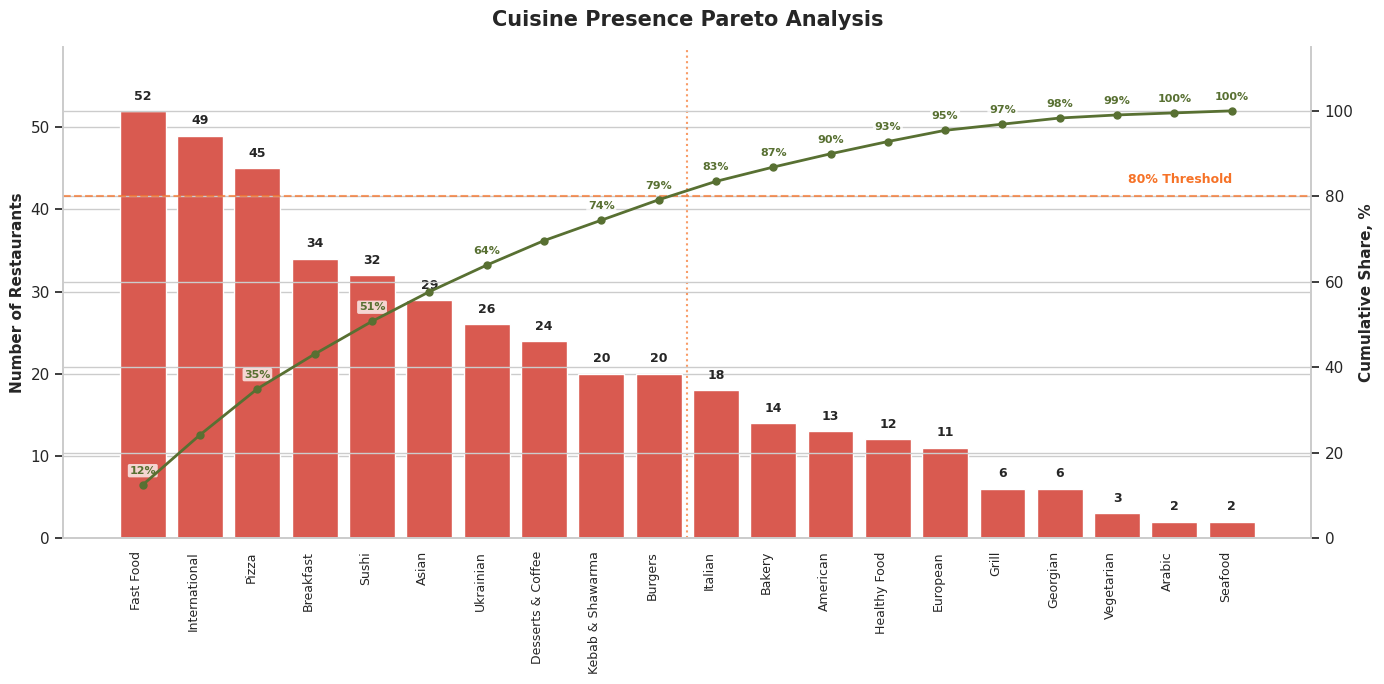

In [11]:
# Visualize Pareto chart for cuisine presence

fig, ax1 = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=cuisine_pareto,
    x="cuisine_type_en",
    y="restaurants",
    color=colors[4],
    ax=ax1
)

for i, value in enumerate(cuisine_pareto["restaurants"]):
    ax1.text(
        i, value + 1, f"{value}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

ax1.set_title("Cuisine Presence Pareto Analysis", fontsize=15, fontweight="bold", pad=15)
ax1.set_xlabel("")
ax1.set_ylabel("Number of Restaurants", fontsize=11, fontweight="bold")
ax1.set_ylim(0, cuisine_pareto["restaurants"].max() * 1.15)
ax1.set_xticks(range(len(cuisine_pareto)))
ax1.set_xticklabels(
    cuisine_pareto["cuisine_type_en"],
    rotation=90, ha="right", fontsize=9
)

ax2 = ax1.twinx()

ax2.plot(
    range(len(cuisine_pareto)),
    cuisine_pareto["cumulative_share_pct"],
    marker="o",
    markersize=5,
    linewidth=2,
    color=colors[0],
    zorder=5
)

for i, value in enumerate(cuisine_pareto["cumulative_share_pct"]):
    if i % 2 == 0 or value >= 79:
        ax2.annotate(
            f"{value:.0f}%",
            xy=(i, value),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color=colors[0],
            fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.75, ec="none")
        )

ax2.set_ylabel("Cumulative Share, %", fontsize=11, fontweight="bold")
ax2.set_ylim(0, 115)
ax2.set_yticks(range(0, 101, 20))

# 80% threshold — horizontal
ax2.axhline(y=80, color=colors[1], linestyle="--", linewidth=1.5, alpha=0.7)
ax2.text(
    len(cuisine_pareto) - 1, 83,
    "80% Threshold",
    color=colors[1], ha="right",
    fontsize=9, fontweight="bold"
)

threshold_idx = cuisine_pareto[cuisine_pareto["cumulative_share_pct"] >= 80].index[0]

# 80% threshold — vertical
ax1.axvline(
    x=threshold_idx - 0.5,
    color=colors[1],
    linestyle=":",
    linewidth=1.5,
    alpha=0.7,
    zorder=2
)

sns.despine(right=False)
plt.tight_layout()
plt.show()

**Cuisine Presence Across Restaurants**

The marketplace contains **20 cuisine tags** after splitting combined cuisine labels.

**Fast Food**, **International**, and **Pizza** are the most represented cuisine segments on the marketplace, indicating intense competition within these categories.

**Sushi** and **Asian** cuisines also maintain a strong presence, while **Ukrainian** cuisine represents a smaller but still significant segment of the market.

The distribution suggests that customer demand is concentrated around a limited number of cuisine types, creating highly competitive conditions for restaurants operating in these segments.

The **top 10 cuisine segments account for approximately 79%** of total cuisine presence, indicating a highly concentrated marketplace. **Fast Food, International, Pizza, Breakfast, and Sushi** alone represent more than **50%** of cuisine presence across restaurants.

This suggests that competition on Glovo is concentrated around a relatively small number of dominant cuisine segments, while the remaining cuisines occupy niche positions.

## **5. Menu Structure Analysis**

### **5.1. Category Group Structure**

In [12]:
# Display all category groups

sorted(df["menu_category_group"].unique())

['Asian Dishes',
 'Bakery',
 'Bestsellers',
 'Bowls',
 'Breakfast',
 'Burgers',
 'Burritos, Wraps & Tacos',
 'Business Lunches',
 'Chebureki & Yantyky',
 'Cold Appetizers',
 'Crepes & Pancakes',
 'Deruny',
 'Desserts',
 'Drinks',
 'Fish & Seafood',
 'Georgian Cuisine',
 'Grill',
 'Hot Appetizers & Fried Snacks',
 'Hot Dogs',
 'Kebabs, Shawarma & Gyros',
 'Kids Menu',
 'Main Dishes',
 'Meat Dishes',
 'New Items',
 'Pasta & Risotto',
 'Pizza',
 'Poultry & Rabbit',
 'Promotions',
 'Salads',
 'Sandwiches & Melts',
 'Sauces & Add-ons',
 'Sets & Combos',
 'Side Dishes',
 'Soups',
 'Special',
 'Sushi & Rolls',
 'Varenyky & Pelmeni']

In [13]:
# Check overlap between merchandising sections and standard menu categories

non_product_categories = [
    "Bestsellers",
    "Promotions",
    "New Items"
]

duplicate_share = (
    df.loc[
        df["menu_category_group"].isin(non_product_categories),
        "dish_name_original"
    ]
    .isin(
        df.loc[
            ~df["menu_category_group"].isin(non_product_categories),
            "dish_name_original"
        ]
    )
    .mean()
)

duplicate_share

np.float64(0.9089820359281438)

The validation showed that approximately **91%** of items listed in **Bestsellers**, **Promotions**, and **New Items** also appear in standard menu categories.

This confirms that these sections primarily serve merchandising and promotional purposes rather than representing distinct product categories. Therefore, they were excluded from the category structure analysis to avoid double-counting menu items.

In [14]:
# Remove non-product categories

product_categories = (
    df.loc[
        ~df["menu_category_group"].isin(non_product_categories)
    ]
)

In [15]:
# Count menu items by category group

category_distribution = (
    product_categories.groupby("menu_category_group")
                      .size()
                      .sort_values(ascending=False)
                      .reset_index(name="menu_items")
)

category_distribution.head(15)

,menu_category_group,menu_items
0,Drinks,2656
1,Desserts,1183
2,Sushi & Rolls,1176
3,Pizza,1015
4,Sets & Combos,1013
5,Main Dishes,953
6,Sauces & Add-ons,951
7,Hot Appetizers & Fried Snacks,895
8,Salads,707
9,Breakfast,487


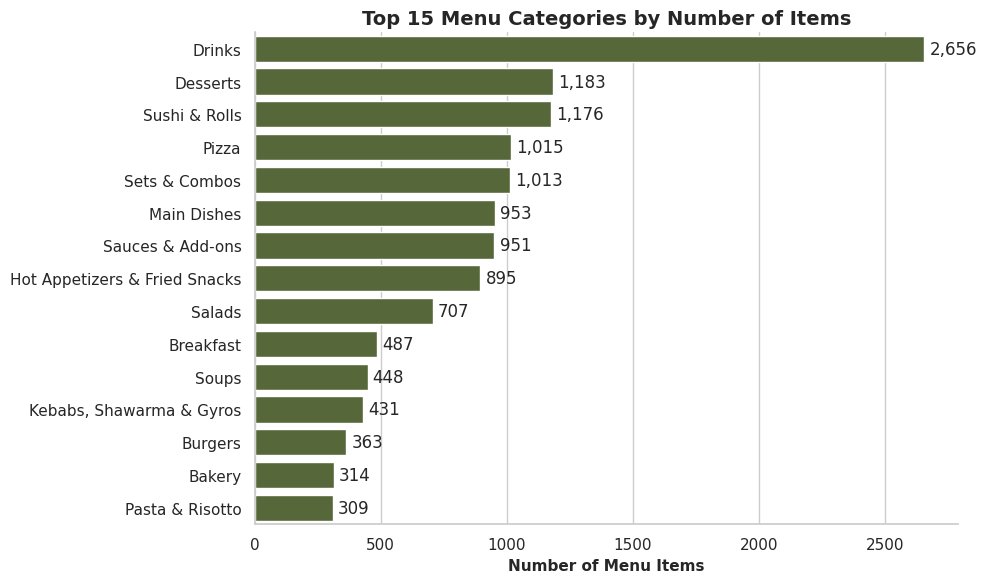

In [16]:
# Visualize top menu categories

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=category_distribution.head(15),
    x="menu_items",
    y="menu_category_group",
    color=colors[0]
)

# Add value labels
for i, value in enumerate(category_distribution.head(15)["menu_items"]):
    ax.text(
        value + 20,
        i,
        f"{value:,}",
        va="center"
    )

plt.title("Top 15 Menu Categories by Number of Items", fontsize=14, fontweight="bold")
plt.xlabel("Number of Menu Items", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

In [17]:
# Calculate category share

category_distribution["share_pct"] = (
    category_distribution["menu_items"]
    / category_distribution["menu_items"].sum()
    * 100
).round(2)

category_distribution.head(15)

,menu_category_group,menu_items,share_pct
0,Drinks,2656,17.63
1,Desserts,1183,7.85
2,Sushi & Rolls,1176,7.81
3,Pizza,1015,6.74
4,Sets & Combos,1013,6.73
5,Main Dishes,953,6.33
6,Sauces & Add-ons,951,6.31
7,Hot Appetizers & Fried Snacks,895,5.94
8,Salads,707,4.69
9,Breakfast,487,3.23


**Category Group Structure Findings**

**Drinks** is the largest category on the marketplace, accounting for **17.6%** of all menu items. It is followed by **Desserts** (7.9%), **Sushi & Rolls** (7.8%), **Pizza** (6.7%), and **Sets & Combos** (6.7%).

The **top 5 categories represent approximately 47%** of total marketplace assortment, while the **top 8 categories account for nearly 69%** of all menu items. This indicates that customer choice is concentrated around a relatively small number of core product categories despite the overall diversity of the marketplace.

The strong presence of drinks, desserts, and add-on categories also suggests that restaurants actively use complementary products to increase basket size and improve order value.

### **5.2. Menu Size Distribution**

In [18]:
# Calculate menu size for each restaurant

menu_size = (
    product_categories.groupby("restaurant_key")
      .size()
      .reset_index(name="menu_items")
)

menu_size.head()

,restaurant_key,menu_items
0,1708-pizza-di-napoli,82
1,2b-fresh-lvi,19
2,3-crowns-lvi,61
3,8-breakfast-pizza-bar-lvi,63
4,ampersand-lvi,36


In [19]:
# Calculate menu size statistics

menu_size_stats = pd.DataFrame({
    "Metric": [
        "Restaurants",
        "Average Menu Size",
        "Median Menu Size",
        "Min Menu Size",
        "Max Menu Size"
    ],
    "Value": [
        menu_size["menu_items"].count(),
        round(menu_size["menu_items"].mean()),
        round(menu_size["menu_items"].median()),
        menu_size["menu_items"].min(),
        menu_size["menu_items"].max()
    ]
})

menu_size_stats

,Metric,Value
0,Restaurants,234
1,Average Menu Size,64
2,Median Menu Size,60
3,Min Menu Size,3
4,Max Menu Size,212


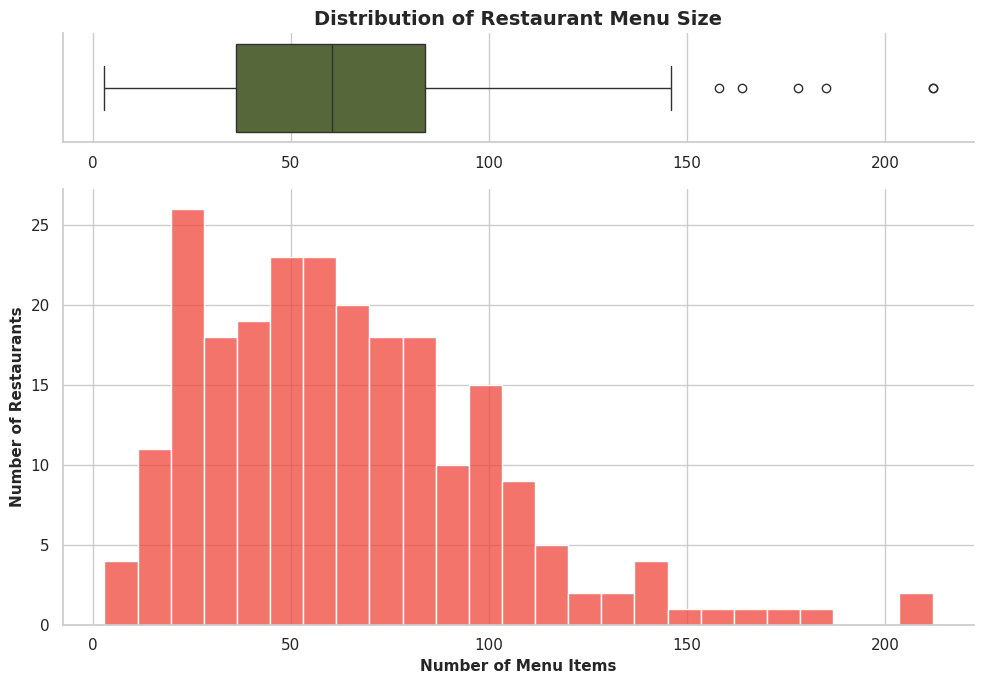

In [20]:
# Visualize menu size distribution

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    gridspec_kw={"height_ratios": [1, 4]}
)

sns.boxplot(data=menu_size, x="menu_items", color=colors[0], ax=ax1)

sns.histplot(
    data=menu_size,
    x="menu_items",
    bins=25,
    color=colors[4],
    ax=ax2
)

ax1.set_title("Distribution of Restaurant Menu Size", fontsize=14, fontweight="bold")
ax1.set_xlabel("")
ax1.set_ylabel("")

ax2.set_xlabel("Number of Menu Items", fontsize=11, fontweight="bold")
ax2.set_ylabel("Number of Restaurants", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()

plt.show()

**Menu Size Distribution Findings**

After removing merchandising sections such as **Bestsellers**, **Promotions**, and **New Items**, the average restaurant offers **64 menu items**, while the median menu contains **60 items**.

Most restaurants operate with menus ranging from approximately **35 to 85 items**, although several restaurants maintain substantially larger assortments.

Menu size varies from just **3 items** to more than **200 items**, highlighting the diversity of assortment strategies across the marketplace. While some restaurants focus on a narrow and specialized offering, others compete through broad product selection and menu variety.

### **5.3. Top Restaurants by Menu Size**

In [21]:
# Calculate menu size by restaurant

restaurant_menu_size = (
    product_categories.groupby(["restaurant_key", "restaurant_name_clean"])
      .size()
      .reset_index(name="menu_items")
      .sort_values("menu_items", ascending=False)
)

restaurant_menu_size.head(10)

,restaurant_key,restaurant_name_clean,menu_items
150,okkokafe-lvi,OKKO CAFÉ,212
156,panda-sushi-lvi,Panda Sushi,212
152,origami-lvi,Origami,185
229,yakuza-sushi-pizza-lvi,Yakuza sushi&pizza,178
145,new-york-street-pizza-zebra-lvi,New York Street Pizza Zebra,164
72,food-garage-lvi,Food Garage,158
77,greengarden,Green Garden,146
128,mcdonald-s-lvi,McDonalds,141
232,zwin-by-shoco-vinnichenka,ZWIN by SHOco Vynnychenka,141
233,zwinbyshoco-lvi,ZWIN by SHOco Kulparkivska,139


In [22]:
# Display restaurants with the smallest menus

restaurant_menu_size.tail(10)

,restaurant_key,restaurant_name_clean,menu_items
88,kebab-chef-lvi,Kebab Chef,17
191,shaurmalviv-lvi,Shaurma Lviv,17
207,svyatoyurska-kavyarnya-lvi,Svyatoyurska Kavyarnya,16
172,red-monkey-lvi,Red Monkey,15
201,snidanki-vid-vishivanki-bistro-lvi,Snidanky vid Vyshyvanky Bistro,13
58,doner-kebab-lvi,Doner Kebab,13
175,rinroll-lvi,RinRoll,10
210,tali-lvi,TALI,6
213,tempo-caffe-lvi,Tempo caffe,6
78,hajp-pica-sushi-lvi,Khaip | Pitsa & Sushi,3


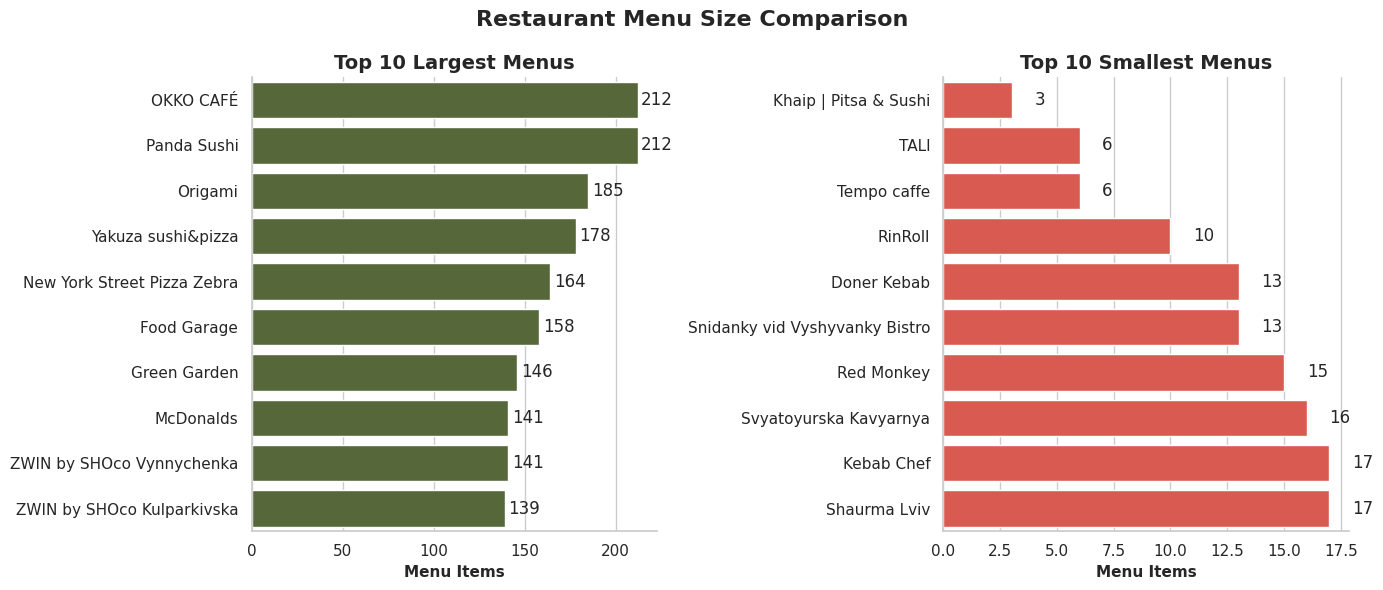

In [23]:
# Visualize restaurants with the largest and smallest menus

top_restaurants = restaurant_menu_size.head(10)
bottom_restaurants = (restaurant_menu_size.sort_values("menu_items").head(10))

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(14, 6)
)

sns.barplot(
    data=top_restaurants,
    x="menu_items",
    y="restaurant_name_clean",
    color=colors[0],
    ax=ax1
)

sns.barplot(
    data=bottom_restaurants,
    x="menu_items",
    y="restaurant_name_clean",
    color=colors[4],
    ax=ax2
)

# Add value labels
for i, value in enumerate(top_restaurants["menu_items"]):
    ax1.text(
        value + 2,
        i,
        f"{value}",
        va="center"
    )

for i, value in enumerate(bottom_restaurants["menu_items"]):
    ax2.text(
        value + 1,
        i,
        f"{value}",
        va="center"
    )

ax1.set_title("Top 10 Largest Menus", fontsize=14, fontweight="bold")
ax2.set_title("Top 10 Smallest Menus", fontsize=14, fontweight="bold")

ax1.set_xlabel("Menu Items", fontsize=11, fontweight="bold")
ax2.set_xlabel("Menu Items", fontsize=11, fontweight="bold")

ax1.set_ylabel("")
ax2.set_ylabel("")

fig.suptitle("Restaurant Menu Size Comparison", fontsize=16, fontweight="bold")

sns.despine()
plt.tight_layout()

plt.show()

**Largest and Smallest Restaurant Menus**

Restaurant menu size varies substantially across the marketplace, reflecting different assortment strategies.

The largest menus contain more than **140 items**, with **Panda Sushi** and **OKKO CAFÉ** offering over **200 products** each. These restaurants follow a broad assortment strategy designed to maximize customer choice and address multiple consumption occasions.

At the opposite end of the spectrum, several restaurants operate with fewer than **20 menu items**. Such focused menus are common among specialized concepts and may help simplify operations while maintaining a clear value proposition.

The contrast between the largest and smallest menus highlights the diversity of business models present on the marketplace.

### **5.4. Menu Size by Cuisine**

In [24]:
# Split cuisine tags for product categories

product_cuisine_tags = (
    product_categories.assign(cuisine_type_en=lambda x: x["cuisine_type_en"].str.split(", "))
                      .explode("cuisine_type_en")
)

In [25]:
# Calculate menu size by restaurant and cuisine

restaurant_cuisine_size = (
    product_cuisine_tags.groupby(["restaurant_key", "cuisine_type_en"])
                        .size()
                        .reset_index(name="menu_items")
)

cuisine_menu_stats = (
    restaurant_cuisine_size.groupby("cuisine_type_en")
    .agg(
        restaurants=("restaurant_key", "nunique"),
        avg_menu_size=("menu_items", "mean"),
        median_menu_size=("menu_items", "median"),
        min_menu_size=("menu_items", "min"),
        max_menu_size=("menu_items", "max"),
        menu_size_std=("menu_items", "std")
    )
    .round(0)
    .sort_values("median_menu_size", ascending=False)
    .reset_index()
)

cuisine_menu_stats

,cuisine_type_en,restaurants,avg_menu_size,median_menu_size,min_menu_size,max_menu_size,menu_size_std
0,American,13,90.0,96.0,28,141,31.0
1,Sushi,32,88.0,83.0,3,212,49.0
2,Desserts & Coffee,24,77.0,80.0,6,178,40.0
3,Asian,29,80.0,72.0,19,185,41.0
4,Burgers,20,76.0,72.0,19,212,43.0
5,European,11,72.0,69.0,24,127,35.0
6,Ukrainian,26,66.0,64.0,24,127,31.0
7,Breakfast,34,70.0,64.0,13,141,33.0
8,Pizza,45,76.0,63.0,3,212,50.0
9,Bakery,14,75.0,62.0,35,141,38.0


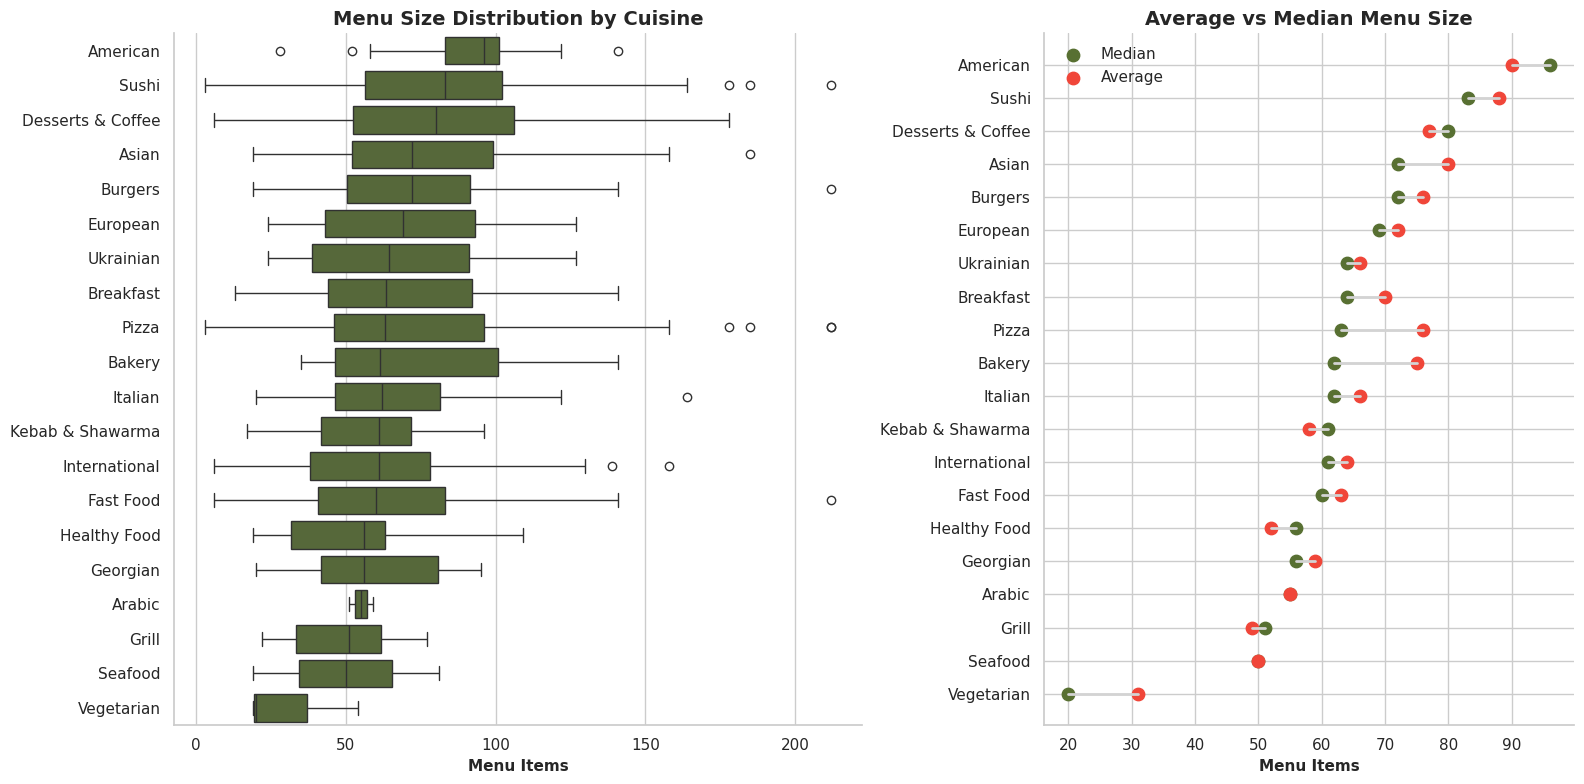

In [26]:
# Visualize menu size by cuisine

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 8),
    gridspec_kw={"width_ratios": [1.3, 1]}
)

sns.boxplot(
    data=restaurant_cuisine_size,
    x="menu_items",
    y="cuisine_type_en",
    order=cuisine_menu_stats["cuisine_type_en"],
    color=colors[0],
    ax=ax1
)

ax1.set_title("Menu Size Distribution by Cuisine", fontsize=14, fontweight="bold")
ax1.set_xlabel("Menu Items", fontsize=11, fontweight="bold")
ax1.set_ylabel("")

for i, (_, row) in enumerate(cuisine_menu_stats.iterrows()):
    ax2.plot(
        [row["median_menu_size"], row["avg_menu_size"]],
        [i, i],
        color="lightgray",
        linewidth=2
    )

    ax2.scatter(
        row["median_menu_size"],
        i,
        s=80,
        color=colors[0],
        label="Median" if i == 0 else ""
    )

    ax2.scatter(
        row["avg_menu_size"],
        i,
        s=80,
        color=colors[4],
        label="Average" if i == 0 else ""
    )

ax2.set_yticks(range(len(cuisine_menu_stats)))
ax2.set_yticklabels(cuisine_menu_stats["cuisine_type_en"])
ax2.invert_yaxis()

ax2.set_title("Average vs Median Menu Size", fontsize=14, fontweight="bold")
ax2.set_xlabel("Menu Items", fontsize=11, fontweight="bold")
ax2.set_ylabel("")

ax2.legend(frameon=False)

sns.despine()
plt.tight_layout()

plt.show()

**Menu Size by Cuisine Findings**

Menu size varies noticeably across cuisine segments.

**American** restaurants have the largest typical assortments, with a median menu size of **96 items**, followed by **Sushi** (83 items), **Desserts & Coffee** (80 items), and **Asian** cuisine (72 items).

At the opposite end, **Vegetarian** (20 items), **Grill** (51 items), **Arabic** (55 items), and **Healthy Food** (56 items) tend to operate with more focused menus.

Several cuisine segments show meaningful differences between average and median menu size. **Sushi, Pizza, Bakery, Burgers,** and **Asian** cuisine have the largest gaps, indicating the presence of restaurants with exceptionally large assortments that increase the segment average.

The largest assortments are concentrated in **American, Sushi, Desserts & Coffee,** and **Asian** segments, suggesting that competition in these cuisines is driven not only by pricing but also by product variety and menu breadth.

*Note: Some cuisine segments, such as Seafood, Arabic, and Vegetarian, are represented by a relatively small number of restaurants. Therefore, their menu size metrics should be interpreted as indicative rather than representative of the broader marketplace.*

## **6. Pricing Analysis**

### **6.1. Price Overview**

In [27]:
# Calculate marketplace price statistics

price_stats = pd.DataFrame({
    "Metric": [
        "Menu Items",
        "Average Price",
        "Median Price",
        "Min Price",
        "25th Percentile",
        "75th Percentile",
        "95th Percentile",
        "Max Price"
    ],
    "Value": [
        len(product_categories),
        round(product_categories["final_price"].mean()),
        round(product_categories["final_price"].median()),
        round(product_categories["final_price"].min()),
        round(product_categories["final_price"].quantile(0.25)),
        round(product_categories["final_price"].quantile(0.75)),
        round(product_categories["final_price"].quantile(0.95)),
        round(product_categories["final_price"].max())
    ]
})

price_stats

,Metric,Value
0,Menu Items,15063
1,Average Price,263
2,Median Price,215
3,Min Price,0
4,25th Percentile,109
5,75th Percentile,330
6,95th Percentile,605
7,Max Price,10666


In [28]:
# Display most expensive menu items

product_categories.nlargest(
    10,
    "final_price"
)[
    [
        "restaurant_name_clean",
        "dish_name_original",
        "final_price"
    ]
]

,restaurant_name_clean,dish_name_original,final_price
8424,Bar Mushly,SEAFOOD BOX великий 4860г,10666.0
8425,Bar Mushly,SEAFOOD BOX середній 3430г,7066.0
8442,Bar Mushly,Лобстер Термідор,5866.0
8443,Bar Mushly,Лобстер Chix з соусом Айолі та овочевою сальсою,5602.0
8426,Bar Mushly,SEAFOOD BOX малий 2230г,4666.0
8427,Bar Mushly,Велике плато морепродуктів (750г),4666.0
8380,ChaChito,Велика тарілка гриль (2250г),3950.0
8444,Bar Mushly,Велике плато гриль (800г),3826.0
5261,Babo Gardens,Велика тарілка грильованих морепродуктів і риб...,3800.0
15337,Roll Club,Найбільший сет !,3243.8


In [29]:
# Display cheapest menu items

product_categories.nsmallest(
    10,
    "final_price"
)[
    [
        "restaurant_name_clean",
        "dish_name_original",
        "final_price"
    ]
]

,restaurant_name_clean,dish_name_original,final_price
3780,Cinnamon Bakery,"Гарячий шоколад ""Класік Original"" Акція",0.01
459,Nectarine,Сніданок,0.10
3852,2b Fresh. Bowl & breakfast,Створи свій боул,0.10
3853,2b Fresh. Bowl & breakfast,Солодкий конструктор,0.10
5079,NEWGREEN,Фіксатор для навчальних паличок,0.11
1504,Dragon Wok,Збірний боул,1.00
1719,Poke LULU,Збери сам,1.00
5743,Magic Bowls,Збірний боул,1.00
9086,Dragon Wok,Збірний боул,1.00
12177,Moment,Склади свій бокс,1.00


In [30]:
# Calculate visualization threshold

price_limit = product_categories["final_price"].quantile(0.99)

print(f"99th percentile: {price_limit:.0f} UAH")

99th percentile: 1315 UAH


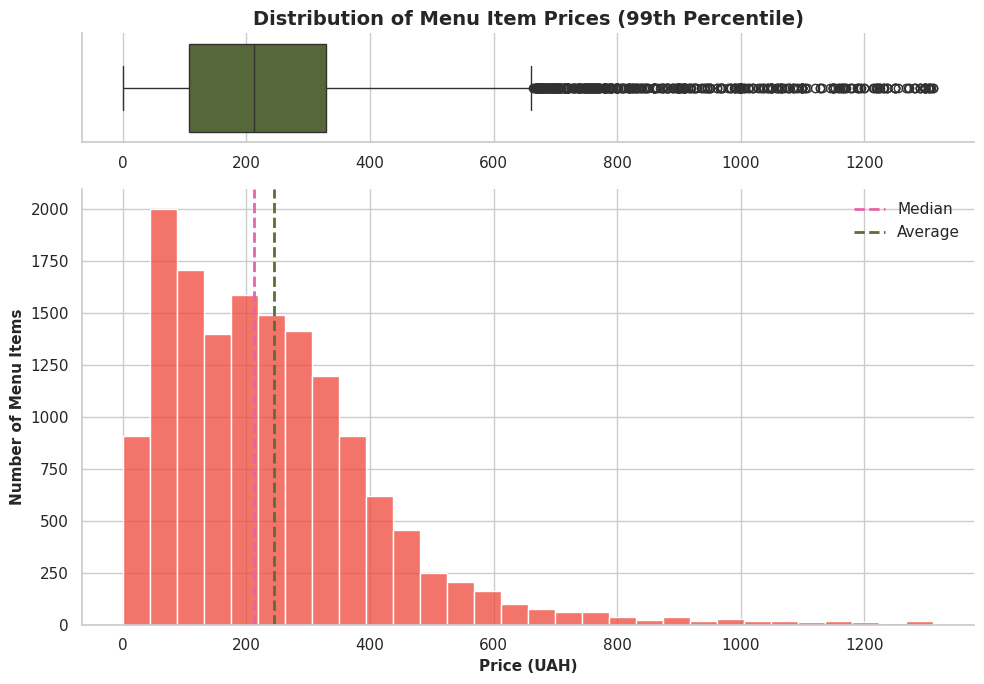

In [31]:
# Visualize price distribution

price_data = product_categories.query("final_price <= @price_limit")

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 7),
    gridspec_kw={"height_ratios": [1, 4]}
)

sns.boxplot(
    data=price_data,
    x="final_price",
    color=colors[0],
    ax=ax1
)

sns.histplot(
    data=price_data,
    x="final_price",
    bins=30,
    color=colors[4],
    ax=ax2
)

ax2.axvline(
    price_data["final_price"].median(),
    color=colors[2],
    linestyle="--",
    linewidth=2,
    label="Median"
)

ax2.axvline(
    price_data["final_price"].mean(),
    color=colors[0],
    linestyle="--",
    linewidth=2,
    label="Average"
)

ax1.set_title(
    "Distribution of Menu Item Prices (99th Percentile)",
    fontsize=14,
    fontweight="bold"
)

ax1.set_xlabel("")
ax1.set_ylabel("")

ax2.set_xlabel("Price (UAH)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Number of Menu Items", fontsize=11, fontweight="bold")

ax2.legend(frameon=False)

sns.despine()
plt.tight_layout()

plt.show()

**Price Overview Findings**

Menu item prices on the marketplace range from symbolic prices used for customizable products to premium seafood platters exceeding **10,000 UAH**.

The **median** menu item price is **215 UAH**, while the **average** price reaches **263 UAH**, indicating a right-skewed distribution driven by a relatively small number of high-priced products.

Half of all menu items are priced between **109 UAH and 330 UAH**, suggesting that the marketplace is largely concentrated in the mid-price segment. Only **5%** of products exceed **605 UAH**, while the most expensive items consist primarily of seafood platters, lobster dishes, and large party sets.

*Note: The lowest observed prices correspond to technical or supporting menu items, such as customizable product builders, disposable utensils, and bread portions, and should not be interpreted as representative of a standard menu item.*

Overall, the pricing structure suggests that Glovo in Lviv is dominated by affordable and mid-range offerings, with a limited number of premium products extending the upper tail of the distribution.

### **6.2. Price by Cuisine**

In [32]:
# Calculate price statistics by cuisine

cuisine_price_stats = (
    product_cuisine_tags.groupby("cuisine_type_en")
    .agg(
        restaurants=("restaurant_key", "nunique"),
        avg_price=("final_price", "mean"),
        median_price=("final_price", "median"),
        min_price=("final_price", "min"),
        max_price=("final_price", "max")
    )
    .round(0)
    .sort_values("avg_price", ascending=False)
    .reset_index()
)

cuisine_price_stats

,cuisine_type_en,restaurants,avg_price,median_price,min_price,max_price
0,Sushi,32,390.0,315.0,0.0,3244.0
1,Asian,29,338.0,279.0,1.0,10666.0
2,Grill,6,336.0,259.0,25.0,2670.0
3,Italian,18,303.0,289.0,14.0,2250.0
4,Pizza,45,295.0,255.0,16.0,2856.0
5,Georgian,6,265.0,205.0,23.0,3950.0
6,Burgers,20,264.0,190.0,17.0,2925.0
7,European,11,261.0,203.0,1.0,2268.0
8,Healthy Food,12,258.0,219.0,0.0,1780.0
9,International,49,255.0,210.0,0.0,3800.0


In [33]:
# Prepare data for visualization

price_chart = (
    cuisine_price_stats
    .assign(price_gap=lambda x: x["avg_price"] - x["median_price"])
    .sort_values("median_price", ascending=False)
)

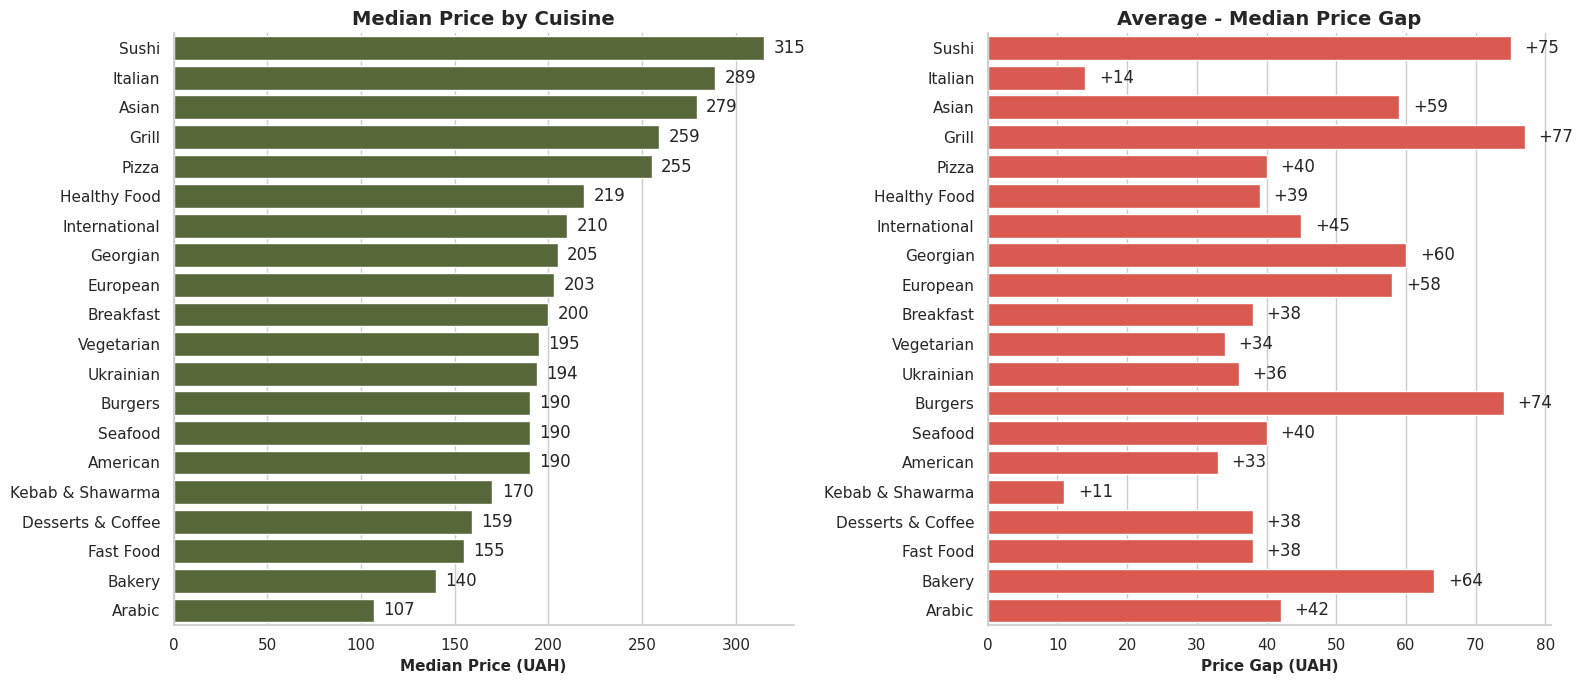

In [34]:
# Visualize prices by cuisine

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7),
    gridspec_kw={"width_ratios": [1.1, 1]}
)

sns.barplot(
    data=price_chart,
    x="median_price",
    y="cuisine_type_en",
    color=colors[0],
    ax=ax1
)

sns.barplot(
    data=price_chart,
    x="price_gap",
    y="cuisine_type_en",
    color=colors[4],
    ax=ax2
)

# Add value labels
for i, value in enumerate(price_chart["median_price"]):
    ax1.text(
        value + 5,
        i,
        f"{value:.0f}",
        va="center"
    )

for i, value in enumerate(price_chart["price_gap"]):
    ax2.text(
        value + 2,
        i,
        f"+{value:.0f}",
        va="center"
    )

ax1.set_title("Median Price by Cuisine", fontsize=14, fontweight="bold")
ax2.set_title("Average - Median Price Gap", fontsize=14, fontweight="bold")

ax1.set_xlabel("Median Price (UAH)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Price Gap (UAH)", fontsize=11, fontweight="bold")

ax1.set_ylabel("")
ax2.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Price by Cuisine Findings**

Pricing varies considerably across cuisine segments.

**Sushi** has the highest median price (**315 UAH**), followed by **Italian** (289 UAH), **Asian** (279 UAH), **Grill** (259 UAH), and **Pizza** (255 UAH). These cuisines represent the premium-priced cuisines of the marketplace.

At the opposite end, **Arabic** (107 UAH), **Bakery** (140 UAH), **Fast Food** (155 UAH), and **Desserts & Coffee** (159 UAH) offer the most affordable products.

Several cuisines show large gaps between average and median prices. **Grill, Sushi, Burgers, Georgian, Asian,** and **European** cuisine have the highest gaps, indicating the presence of premium sets, large platters, and specialty items that substantially increase average prices.

Overall, **median price** provides a more reliable measure of typical customer spending, while the **average-median gap** highlights cuisines with strong premium product offerings.

### **6.3. Price by Category**

In [35]:
# Calculate price statistics by category

category_price_stats = (
    product_categories.groupby("menu_category_group")
    .agg(
        menu_items=("dish_name_original", "count"),
        avg_price=("final_price", "mean"),
        median_price=("final_price", "median"),
        min_price=("final_price", "min"),
        max_price=("final_price", "max")
    )
    .round(0)
    .sort_values("median_price", ascending=False)
    .reset_index()
)

category_price_stats

,menu_category_group,menu_items,avg_price,median_price,min_price,max_price
0,"Burritos, Wraps & Tacos",35,365.0,404.0,173.0,559.0
1,Sets & Combos,1013,636.0,396.0,1.0,10666.0
2,Fish & Seafood,143,484.0,394.0,82.0,3800.0
3,Grill,86,496.0,350.0,90.0,2670.0
4,Meat Dishes,153,478.0,350.0,76.0,3950.0
5,Burgers,363,349.0,345.0,48.0,2925.0
6,Pasta & Risotto,309,366.0,339.0,75.0,1290.0
7,Pizza,1015,347.0,335.0,35.0,799.0
8,Bowls,123,311.0,324.0,0.0,504.0
9,Business Lunches,56,304.0,318.0,199.0,519.0


In [36]:
# Display most expensive products in categories

category_price_stats.nlargest(
    10,
    "max_price"
)[
    [
        "menu_category_group",
        "max_price"
    ]
]

,menu_category_group,max_price
1,Sets & Combos,10666.0
23,Hot Appetizers & Fried Snacks,5866.0
12,Cold Appetizers,4666.0
4,Meat Dishes,3950.0
2,Fish & Seafood,3800.0
5,Burgers,2925.0
3,Grill,2670.0
14,Main Dishes,2550.0
30,Desserts,1660.0
32,Drinks,1374.0


In [37]:
# Calculate price gap

category_price_stats["price_gap"] = (
    category_price_stats["avg_price"]
    - category_price_stats["median_price"]
)

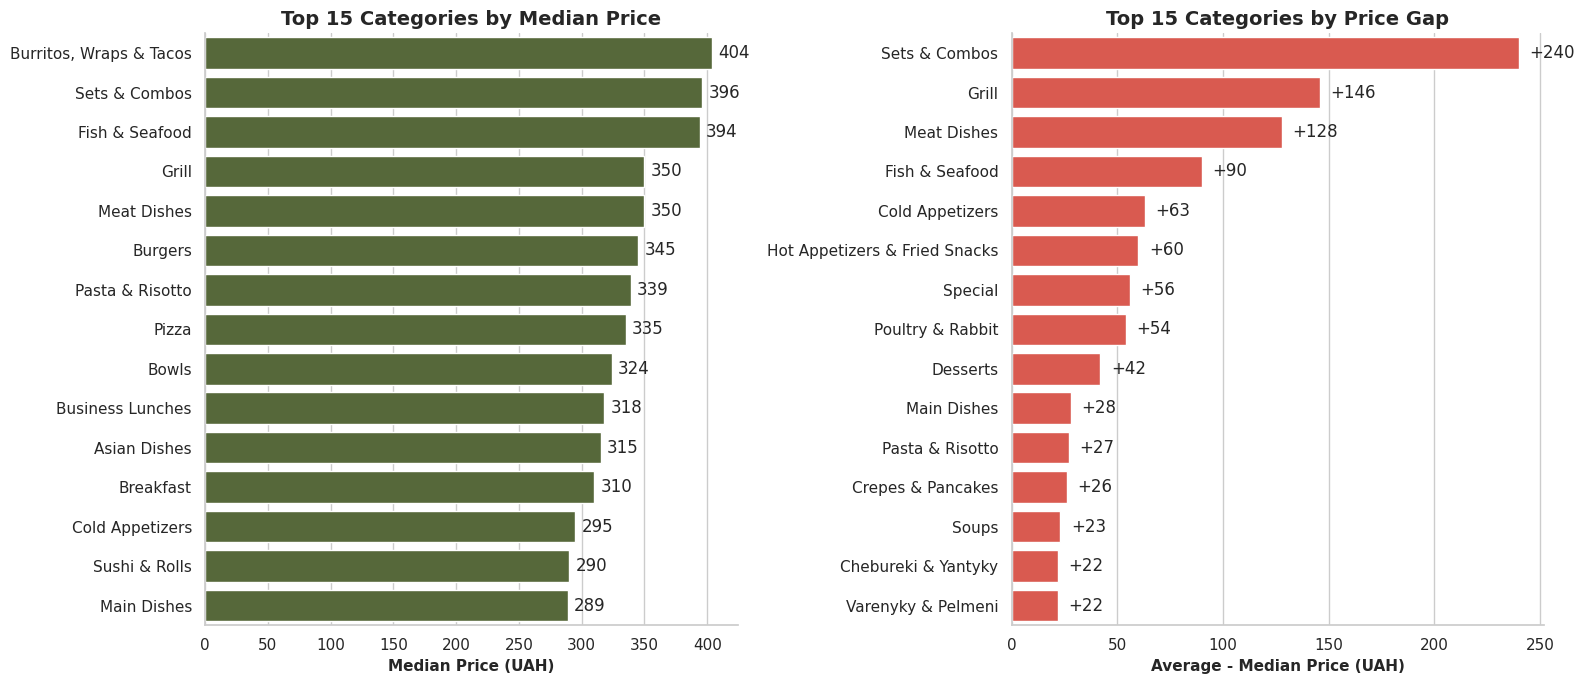

In [38]:
# Visualize category pricing

median_chart = category_price_stats.sort_values("median_price", ascending=False).head(15)
gap_chart = category_price_stats.sort_values("price_gap", ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=median_chart, x="median_price", y="menu_category_group", color=colors[0], ax=ax1)
sns.barplot(data=gap_chart, x="price_gap", y="menu_category_group", color=colors[4], ax=ax2)

for i, value in enumerate(median_chart["median_price"]):
    ax1.text(value + 5, i, f"{value:.0f}", va="center")

for i, value in enumerate(gap_chart["price_gap"]):
    ax2.text(value + 5, i, f"+{value:.0f}", va="center")

ax1.set_title("Top 15 Categories by Median Price", fontsize=14, fontweight="bold")
ax2.set_title("Top 15 Categories by Price Gap", fontsize=14, fontweight="bold")

ax1.set_xlabel("Median Price (UAH)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Average - Median Price (UAH)", fontsize=11, fontweight="bold")

ax1.set_ylabel("")
ax2.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Price by Category Findings**

Pricing differs substantially across menu categories (34 in total).

**Burritos, Wraps & Tacos** has the highest median price (**404 UAH**), followed by **Sets & Combos** (396 UAH), **Fish & Seafood** (394 UAH), **Grill** (350 UAH), and **Meat Dishes** (350 UAH). These categories represent the premium end of the marketplace and are largely associated with sharing meals, large portions, and specialty products.

**Pasta & Risotto** (339 UAH), **Pizza** (335 UAH), **Bowls** (324 UAH), **Business Lunches** (318 UAH), and **Asian Dishes** (315 UAH) also rank among the top 10 categories by median price, reflecting a broader premium segment beyond large-format meals.

The largest price gaps are observed in **Sets & Combos** (+240 UAH), **Grill** (+146 UAH), **Meat Dishes** (+128 UAH), and **Fish & Seafood** (+90 UAH). This indicates the presence of exceptionally expensive items that substantially increase average prices within these categories.

The maximum observed prices confirm this pattern. **Sets & Combos** contains products priced up to **10,666 UAH**, while **Hot Appetizers & Fried Snacks** (5,866 UAH), **Cold Appetizers** (4,666 UAH), **Meat Dishes** (3,950 UAH), and **Fish & Seafood** (3,800 UAH) also include premium offerings far above the typical category price level.

In contrast, high-volume categories such as **Drinks, Desserts, Bakery,** and **Sauces & Add-ons** remain among the most affordable segments of the marketplace.

Overall, premium pricing on Glovo is concentrated in large-format meals, combo offers, meat platters, and seafood products rather than everyday menu items.

## **7. Discount Analysis**

### **7.1. Discount Overview**

In [39]:
# Calculate discount statistics

discount_stats = pd.DataFrame({
    "Metric": [
        "Menu Items",
        "Discounted Items",
        "Discount Share (%)",
        "Average Discount (%)",
        "Median Discount (%)",
        "Max Discount (%)"
    ],
    "Value": [
        len(product_categories),
        product_categories["is_discounted"].sum(),
        round(product_categories["is_discounted"].mean() * 100, 1),
        round(product_categories.loc[
            product_categories["is_discounted"],
            "discount_pct"
        ].mean(), 1),
        round(product_categories.loc[
            product_categories["is_discounted"],
            "discount_pct"
        ].median(), 1),
        round(product_categories["discount_pct"].max(), 1)
    ]
})

discount_stats

,Metric,Value
0,Menu Items,15063.0
1,Discounted Items,2003.0
2,Discount Share (%),13.3
3,Average Discount (%),15.3
4,Median Discount (%),10.0
5,Max Discount (%),50.0


In [40]:
# Discount percentage distribution

product_categories.loc[
    product_categories["is_discounted"],
    "discount_pct"
].describe()

,discount_pct
count,2003.000000
mean,15.288118
std,7.148075
min,10.000000
25%,10.000000
50%,10.000000
75%,20.000000
max,50.000000


In [41]:
# Discount distribution

discount_distribution = (
    product_categories.loc[
        product_categories["is_discounted"],
        "discount_pct"
    ]
    .value_counts()
    .sort_index()
    .reset_index()
)

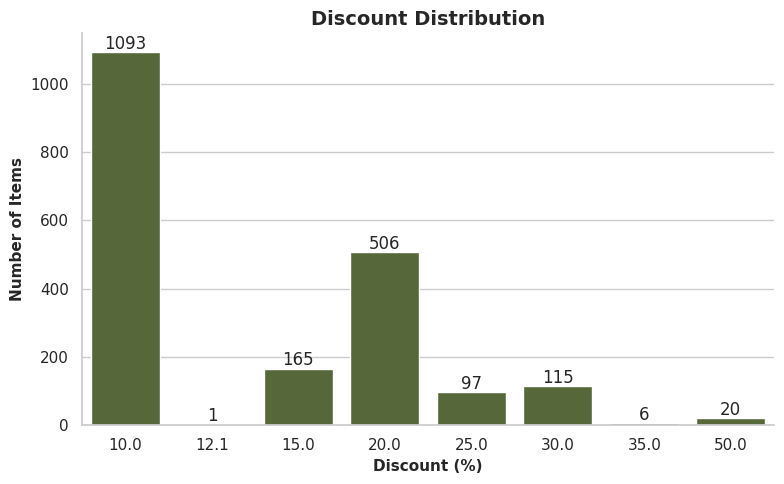

In [42]:
# Visualize discount distribution

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=discount_distribution,
    x="discount_pct",
    y="count",
    color=colors[0]
)

# Add value labels
for i, value in enumerate(discount_distribution["count"]):
    ax.text(
        i,
        value + 10,
        f"{value}",
        ha="center"
    )

plt.title("Discount Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Discount (%)", fontsize=11, fontweight="bold")
plt.ylabel("Number of Items", fontsize=11, fontweight="bold")

sns.despine()
plt.tight_layout()

plt.show()

**Discount Overview Findings**

Discounting is relatively limited across the marketplace. Only **13.3%** of menu items are currently offered at a discounted price, indicating that most restaurants compete through their standard pricing rather than frequent promotions.

The typical discount level is modest. The **median discount equals 10%**, while the **average discount reaches 15.3%**. This suggests that most promotions are concentrated around small price reductions, with a limited number of larger campaigns increasing the average.

Discount levels are highly standardized. More than half of all discounted products receive a **10% discount**, while another **25%** receive a **20% discount**. Together, these two discount levels account for nearly **80%** of all promotions on the marketplace.

Although discounts of 30-50% exist, they represent only a small fraction of promotional activity.

Overall, Glovo restaurants in Lviv appear to use discounts as a **tactical promotional tool** rather than as a primary pricing strategy.

### **7.2. Discounts by Cuisine**

In [43]:
# Calculate discount statistics by cuisine

cuisine_discount_stats = (
    product_cuisine_tags.groupby("cuisine_type_en")
    .agg(
        menu_items=("dish_name_original", "count"),
        discounted_items=("is_discounted", "sum"),
        avg_discount=("discount_pct", "mean"),
        median_discount=("discount_pct", "median")
    )
    .fillna(0)
    .reset_index()
)

cuisine_discount_stats["discount_share"] = (
    cuisine_discount_stats["discounted_items"]
    / cuisine_discount_stats["menu_items"]
    * 100
)

cuisine_discount_stats = (
    cuisine_discount_stats
    .round(1)
    .sort_values("discount_share", ascending=False)
)

cuisine_discount_stats

,cuisine_type_en,menu_items,discounted_items,avg_discount,median_discount,discount_share
6,Desserts & Coffee,1856,721,10.1,10.0,38.8
14,Kebab & Shawarma,1167,371,19.2,20.0,31.8
19,Vegetarian,93,20,50.0,50.0,21.5
8,Fast Food,3273,512,18.2,20.0,15.6
13,Italian,1190,148,18.2,10.0,12.4
12,International,3114,352,10.3,10.0,11.3
17,Sushi,2807,307,22.2,20.0,10.9
4,Breakfast,2376,209,14.4,10.0,8.8
5,Burgers,1523,130,17.1,15.0,8.5
7,European,792,67,19.7,20.0,8.5


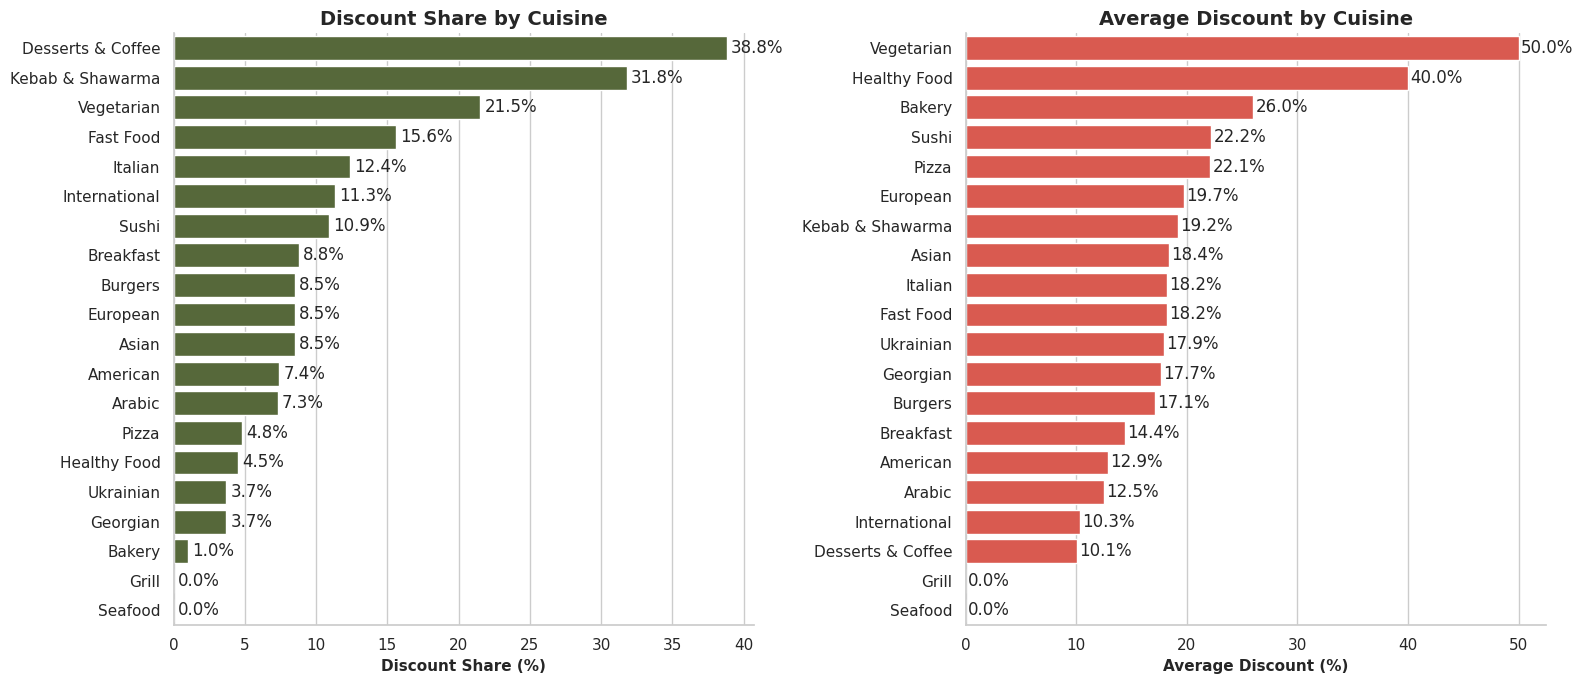

In [44]:
# Visualize discounts by cuisine

fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(16, 7)
)

sns.barplot(
    data=cuisine_discount_stats,
    x="discount_share",
    y="cuisine_type_en",
    color=colors[0],
    ax=ax1
)

sns.barplot(
    data=cuisine_discount_stats.sort_values("avg_discount", ascending=False),
    x="avg_discount",
    y="cuisine_type_en",
    color=colors[4],
    ax=ax2
)

# Add value labels
for i, value in enumerate(cuisine_discount_stats["discount_share"]):
    ax1.text(
        value + 0.3,
        i,
        f"{value:.1f}%",
        va="center"
    )

for i, value in enumerate(
    cuisine_discount_stats.sort_values("avg_discount", ascending=False)["avg_discount"]
):
    ax2.text(
        value + 0.2,
        i,
        f"{value:.1f}%",
        va="center"
    )

ax1.set_title("Discount Share by Cuisine", fontsize=14, fontweight="bold")
ax2.set_title("Average Discount by Cuisine", fontsize=14, fontweight="bold")

ax1.set_xlabel("Discount Share (%)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Average Discount (%)", fontsize=11, fontweight="bold")

ax1.set_ylabel("")
ax2.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Discounts by Cuisine Findings**

Promotional activity varies significantly across cuisine segments.

**Desserts & Coffee** is the most promotion-intensive cuisine on the marketplace, with **38.8%** of menu items offered at a discounted price. **Kebab & Shawarma** follows with **31.8%**, while **Vegetarian** (21.5%) and **Fast Food** (15.6%) also rely heavily on promotions.

The relationship between discount frequency and discount depth differs across cuisines. **Desserts & Coffee** uses discounts very frequently but typically offers only **10%** reductions, indicating a strategy focused on constant visibility rather than aggressive price cuts.

**Pizza** presents the opposite pattern: only **4.8%** of menu items are discounted, but when promotions are applied, they tend to be deep — averaging **22.1%**, among the highest of any major cuisine alongside **Sushi** (22.2%). This suggests Pizza restaurants use promotions selectively but with stronger impact when activated, rather than relying on frequent low-value discounts.

The largest average discounts overall are observed in **Vegetarian** (50%) and **Healthy Food** (40%) cuisines. However, these segments represent relatively small portions of the marketplace and are likely influenced by a limited number of promotional campaigns.

Overall, the results indicate that restaurants follow different promotional strategies. Some cuisines compete through frequent low-discount offers, while others rely on occasional but more substantial price reductions.

### **7.3. Discounts by Category**

In [45]:
# Calculate discount statistics by category

category_discount_stats = (
    product_categories.groupby("menu_category_group")
    .agg(
        menu_items=("dish_name_original", "count"),
        discounted_items=("is_discounted", "sum"),
        avg_discount=("discount_pct", "mean"),
        median_discount=("discount_pct", "median")
    )
    .fillna(0)
    .reset_index()
)

category_discount_stats["discount_share"] = (
    category_discount_stats["discounted_items"]
    / category_discount_stats["menu_items"]
    * 100
)

category_discount_stats = (
    category_discount_stats
    .round(1)
    .sort_values("discount_share", ascending=False)
)

category_discount_stats

,menu_category_group,menu_items,discounted_items,avg_discount,median_discount,discount_share
5,"Burritos, Wraps & Tacos",35,28,12.5,10.0,80.0
31,Special,122,60,10.2,10.0,49.2
18,"Kebabs, Shawarma & Gyros",431,139,21.2,20.0,32.3
26,Sandwiches & Melts,198,62,10.2,10.0,31.3
10,Deruny,81,23,15.1,15.0,28.4
2,Bowls,123,29,16.0,10.0,23.6
3,Breakfast,487,110,10.4,10.0,22.6
28,Sets & Combos,1013,220,17.6,20.0,21.7
22,Pasta & Risotto,309,60,12.7,10.0,19.4
17,Hot Dogs,110,21,10.0,10.0,19.1


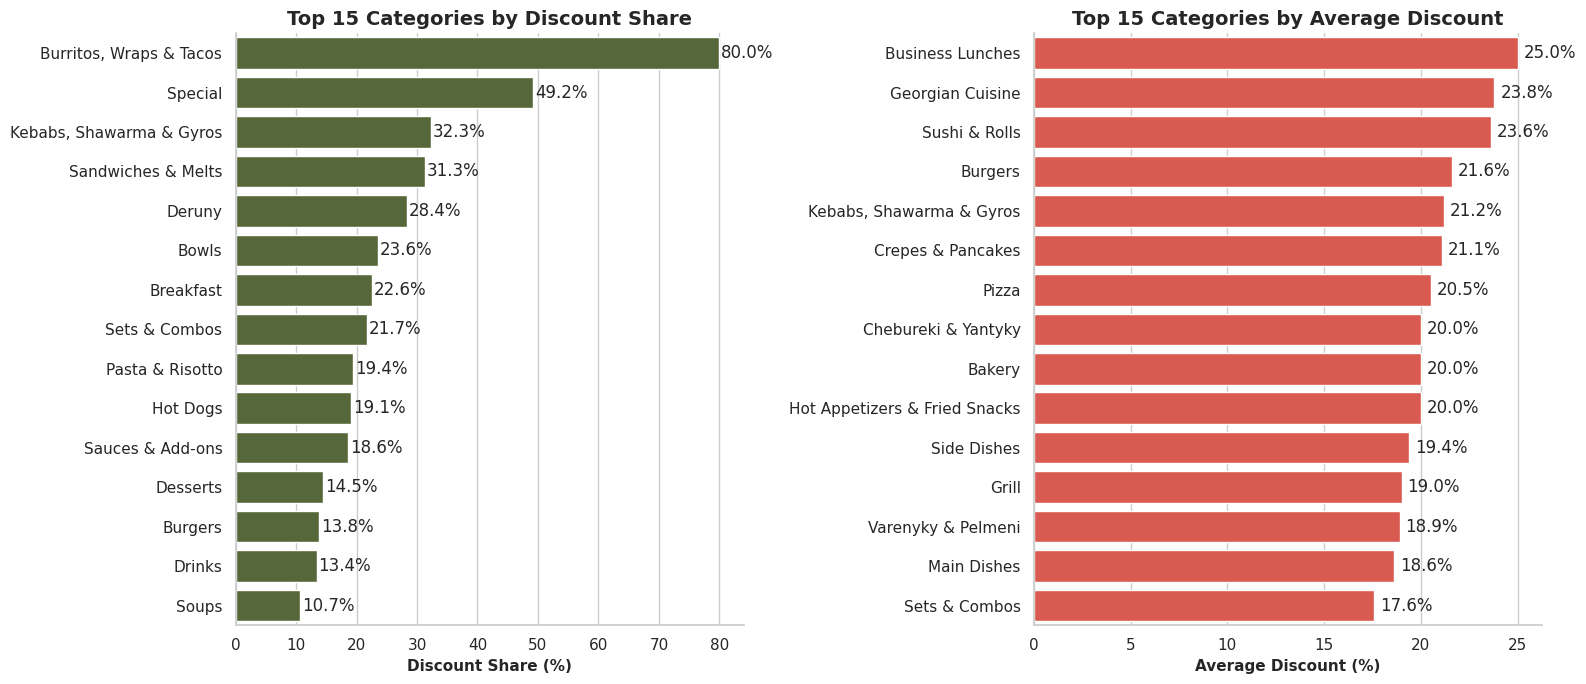

In [46]:
# Visualize discounts by category

discount_share_chart = category_discount_stats.sort_values("discount_share", ascending=False).head(15)
avg_discount_chart = category_discount_stats.sort_values("avg_discount", ascending=False).head(15)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

sns.barplot(data=discount_share_chart, x="discount_share", y="menu_category_group", color=colors[0], ax=ax1)
sns.barplot(data=avg_discount_chart, x="avg_discount", y="menu_category_group", color=colors[4], ax=ax2)

for i, value in enumerate(discount_share_chart["discount_share"]):
    ax1.text(value + 0.3, i, f"{value:.1f}%", va="center")

for i, value in enumerate(avg_discount_chart["avg_discount"]):
    ax2.text(value + 0.3, i, f"{value:.1f}%", va="center")

ax1.set_title("Top 15 Categories by Discount Share", fontsize=14, fontweight="bold")
ax2.set_title("Top 15 Categories by Average Discount", fontsize=14, fontweight="bold")

ax1.set_xlabel("Discount Share (%)", fontsize=11, fontweight="bold")
ax2.set_xlabel("Average Discount (%)", fontsize=11, fontweight="bold")

ax1.set_ylabel("")
ax2.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Discounts by Category Findings**

Promotional activity varies considerably across menu categories.

**Burritos, Wraps & Tacos** is the most promotion-intensive category on the marketplace, with **80.0%** of menu items offered at a discounted price. **Special** (49.2%), **Kebabs, Shawarma & Gyros** (32.3%), **Sandwiches & Melts** (31.3%), and **Deruny** (28.4%) also rely heavily on promotional pricing.

However, categories with the highest promotional coverage do not necessarily offer the largest discounts. **Burritos, Wraps & Tacos** discounts most of its products, yet the average discount is only **12.5%**, indicating a strategy focused on frequent visibility rather than aggressive price reductions.

In contrast, categories such as **Sushi & Rolls** (23.6% average discount), **Georgian Cuisine** (23.8%), **Burgers** (21.6%), **Pizza** (20.5%), and **Kebabs, Shawarma & Gyros** (21.2%) offer substantially larger discounts when promotions are applied. These categories appear to use fewer but more impactful promotional campaigns.

**Sets & Combos** represents a balanced promotional strategy. More than **21%** of menu items are discounted, while the average discount reaches **17.6%**, suggesting a combination of relatively frequent and meaningful promotions.

Several categories show very limited promotional activity, including **Kids Menu** (0%), **Cold Appetizers** (0.9%), **Bakery** (1.3%), and **Chebureki & Yantyky** (1.4%).

Overall, the results reveal two distinct promotional approaches across the marketplace: **frequent low-discount campaigns** designed to maintain visibility and customer engagement, and **selective high-discount campaigns** aimed at stimulating demand within specific product categories.

## **8. Bestseller Merchandising Analysis**

### **8.1. Bestseller Overview**


In [47]:
# Bestseller items

bestsellers = (
    df[df["menu_category_group"] == "Bestsellers"]
)

bestseller_stats = pd.DataFrame({
    "Metric": [
        "Bestseller Items",
        "Unique Bestseller Dishes",
        "Restaurants with Bestsellers",
        "Bestseller Share (%)"
    ],
    "Value": [
        len(bestsellers),
        bestsellers["dish_name_original"].nunique(),
        bestsellers["restaurant_key"].nunique(),
        round(
            len(bestsellers)
            / len(df)
            * 100,
            1
        )
    ]
})

bestseller_stats

,Metric,Value
0,Bestseller Items,516.0
1,Unique Bestseller Dishes,476.0
2,Restaurants with Bestsellers,194.0
3,Bestseller Share (%),3.2


**Bestseller Overview**

The marketplace contains **516 bestseller listings**, representing **476 unique dishes** across **194 restaurants**.

Despite representing only **3.2%** of marketplace assortment, bestseller items receive disproportionate visibility through dedicated merchandising sections and therefore likely influence customer attention more than their numerical share suggests.

The difference between total bestseller listings and unique bestseller dishes is relatively small, indicating limited duplication within bestseller sections.

Most restaurants on the marketplace use bestseller blocks as a merchandising tool. Approximately **83%** of restaurants feature at least one bestseller item, highlighting the widespread adoption of curated product recommendations.

### **8.2. Bestseller by Cuisine**

In [48]:
# Split cuisine tags for bestseller analysis

bestseller_cuisine_tags = (
    bestsellers.assign(
        cuisine_type_en=lambda x: x["cuisine_type_en"].str.split(", ")
    )
    .explode("cuisine_type_en")
)

In [49]:
# Calculate bestseller share by cuisine

cuisine_bestseller_stats = (
    bestseller_cuisine_tags.groupby("cuisine_type_en")
    .agg(
        bestseller_items=("dish_name_original", "count")
    )
    .reset_index()
)

cuisine_bestseller_stats = (
    cuisine_bestseller_stats.merge(
        cuisine_tags.groupby("cuisine_type_en")
        .size()
        .reset_index(name="menu_items"),
        on="cuisine_type_en"
    )
)

cuisine_bestseller_stats["bestseller_share"] = (
    cuisine_bestseller_stats["bestseller_items"]
    / cuisine_bestseller_stats["menu_items"]
    * 100
)

cuisine_bestseller_stats = (
    cuisine_bestseller_stats
    .sort_values("bestseller_share", ascending=False)
    .round(1)
)

cuisine_bestseller_stats

,cuisine_type_en,bestseller_items,menu_items,bestseller_share
10,Grill,18,312,5.8
14,Kebab & Shawarma,57,1261,4.5
9,Georgian,16,378,4.2
19,Vegetarian,4,100,4.0
18,Ukrainian,64,1817,3.5
11,Healthy Food,23,661,3.5
8,Fast Food,118,3473,3.4
13,Italian,41,1249,3.3
2,Asian,78,2446,3.2
7,European,26,842,3.1


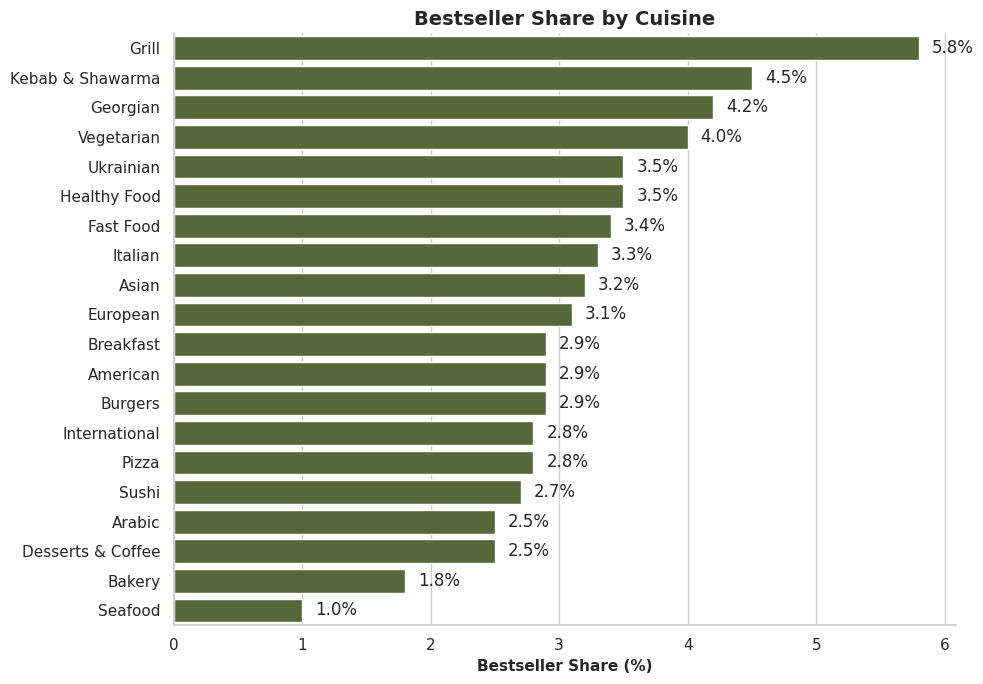

In [50]:
# Visualize bestseller share by cuisine

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=cuisine_bestseller_stats,
    x="bestseller_share",
    y="cuisine_type_en",
    color=colors[0]
)

for i, value in enumerate(cuisine_bestseller_stats["bestseller_share"]):
    ax.text(value + 0.1, i, f"{value:.1f}%", va="center")

plt.title("Bestseller Share by Cuisine", fontsize=14, fontweight="bold")
plt.xlabel("Bestseller Share (%)", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Bestsellers by Cuisine Findings**

Bestseller concentration varies across cuisine segments.

Although **Grill** shows the highest bestseller share (**5.8%**), the segment is represented by only a small number of restaurants. **Kebab & Shawarma** (4.5%), **Georgian** (4.2%), and **Vegetarian** (4.0%) also show above-average use of bestseller merchandising.

Among major cuisine segments, **Fast Food** (3.4%), **Italian** (3.3%), **Asian** (3.2%), and **Ukrainian** (3.5%) show relatively strong bestseller representation.

**Pizza** and **Sushi** generate many bestseller items in absolute terms, but their bestseller share remains close to the marketplace average due to their large menu assortment.

Overall, bestseller sections appear to be used most actively by more focused cuisine segments, where a smaller number of flagship products can play a stronger role in attracting customer attention.

### **8.3. Bestsellers by Category**

In [51]:
# Match bestseller dishes with product categories

bestseller_categories = (
    bestsellers[
        [
            "restaurant_key",
            "dish_name_original"
        ]
    ]
    .merge(
        product_categories[
            [
                "restaurant_key",
                "dish_name_original",
                "menu_category_group"
            ]
        ],
        on=["restaurant_key", "dish_name_original"],
        how="left"
    )
)

In [52]:
# Calculate bestseller share by category

category_bestseller_stats = (
    bestseller_categories.dropna(subset=["menu_category_group"])
    .groupby("menu_category_group")
    .agg(bestseller_items=("dish_name_original", "count"))
    .reset_index()
)

category_bestseller_stats = (
    category_bestseller_stats.merge(
        product_categories.groupby("menu_category_group")
        .size()
        .reset_index(name="menu_items"),
        on="menu_category_group"
    )
)

category_bestseller_stats["bestseller_share"] = (
    category_bestseller_stats["bestseller_items"]
    / category_bestseller_stats["menu_items"]
    * 100
)

category_bestseller_stats = (
    category_bestseller_stats
    .round(1)
    .sort_values("bestseller_share", ascending=False)
)

category_bestseller_stats

,menu_category_group,bestseller_items,menu_items,bestseller_share
6,Business Lunches,11,56,19.6
5,"Burritos, Wraps & Tacos",6,35,17.1
18,"Kebabs, Shawarma & Gyros",62,431,14.4
14,Georgian Cuisine,10,73,13.7
25,Sandwiches & Melts,25,198,12.6
0,Asian Dishes,14,158,8.9
10,Deruny,7,81,8.6
20,Meat Dishes,13,153,8.5
4,Burgers,28,363,7.7
26,Sets & Combos,73,1013,7.2


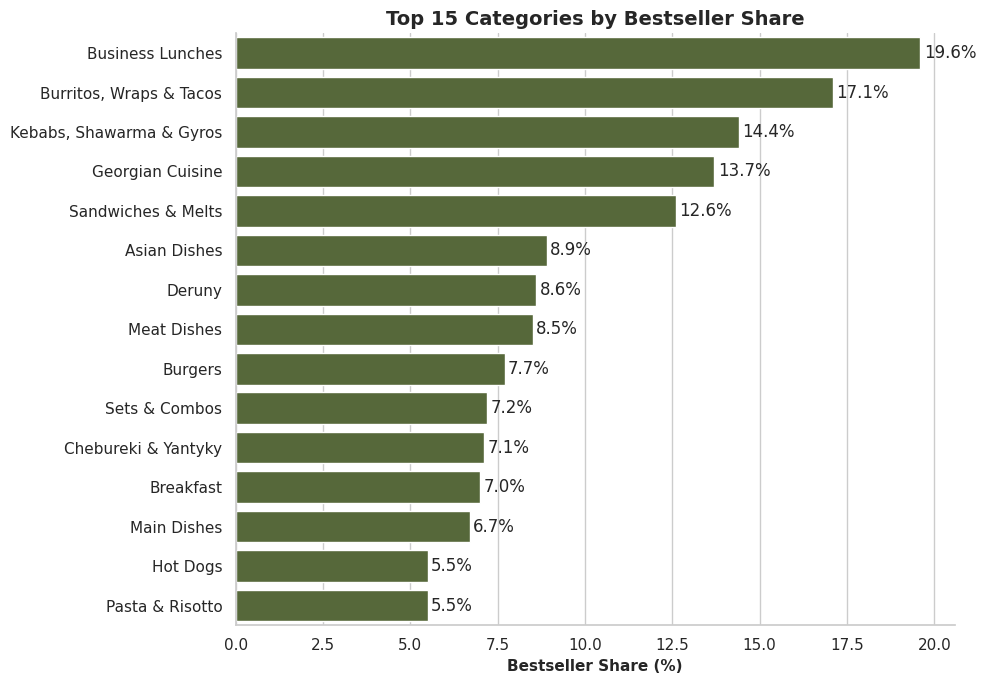

In [53]:
# Visualize bestseller share by category

chart = (
    category_bestseller_stats
    .head(15)
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=chart,
    x="bestseller_share",
    y="menu_category_group",
    color=colors[0]
)

for i, value in enumerate(chart["bestseller_share"]):
    ax.text(
        value + 0.1,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.title("Top 15 Categories by Bestseller Share", fontsize=14, fontweight="bold")
plt.xlabel("Bestseller Share (%)", fontsize=11, fontweight="bold")
plt.ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Bestsellers by Category Findings**

Bestseller concentration varies substantially across menu categories.

**Business Lunches** has the highest bestseller share on the marketplace, with **19.6%** of all products featured in bestseller sections. **Burritos, Wraps & Tacos** (17.1%), **Kebabs, Shawarma & Gyros** (14.4%), **Georgian Cuisine** (13.7%), and **Sandwiches & Melts** (12.6%) also show strong bestseller representation.

These categories are typically built around a limited number of flagship products, making it easier for restaurants to concentrate customer demand on a small set of popular items.

Large marketplace categories demonstrate a different pattern. **Sets & Combos** (7.2%), **Main Dishes** (6.7%), **Breakfast** (7.0%), **Burgers** (7.7%), and **Pizza** (5.4%) generate many bestseller products in absolute terms, but their bestseller share remains lower because of their broader assortment.

At the opposite end, **Drinks** (0.2%), **Desserts** (0.3%), **Bakery** (0.6%), and **Sushi & Rolls** (0.9%) rarely appear in bestseller sections relative to their category size.

Overall, bestseller merchandising appears to be concentrated in categories where customer choice is relatively focused, while broad assortment categories rely less on highlighting individual products.

## **9. Market Segmentation**

### **9.1. Price Segments and Promotion Strategy**

In [54]:
# Calculate restaurant-level metrics

restaurant_segments = (
    product_categories.groupby(
        ["restaurant_key", "restaurant_name_clean"]
    )
    .agg(
        median_price=("final_price", "median"),
        menu_items=("dish_name_original", "count"),
        discount_share=("is_discounted", "mean")
    )
    .reset_index()
)

restaurant_segments["discount_share"] *= 100

In [55]:
# Create price segments

restaurant_segments["price_segment"] = pd.qcut(
    restaurant_segments["median_price"],
    q=3,
    labels=[
        "Budget",
        "Mid-range",
        "Premium"
    ]
)

In [56]:
# Calculate summary metrics by price segment

segment_stats = (
    restaurant_segments.groupby("price_segment")
    .agg(
        restaurants=("restaurant_key", "count"),
        median_price=("median_price", "median"),
        median_menu_size=("menu_items", "median"),
        avg_discount_share=("discount_share", "mean")
    )
    .round(1)
    .reset_index()
)

segment_stats

/tmp/ipykernel_8565/276898737.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  restaurant_segments.groupby("price_segment")


,price_segment,restaurants,median_price,median_menu_size,avg_discount_share
0,Budget,78,139.5,60.0,16.4
1,Mid-range,78,216.7,58.5,12.9
2,Premium,78,319.0,63.0,5.0


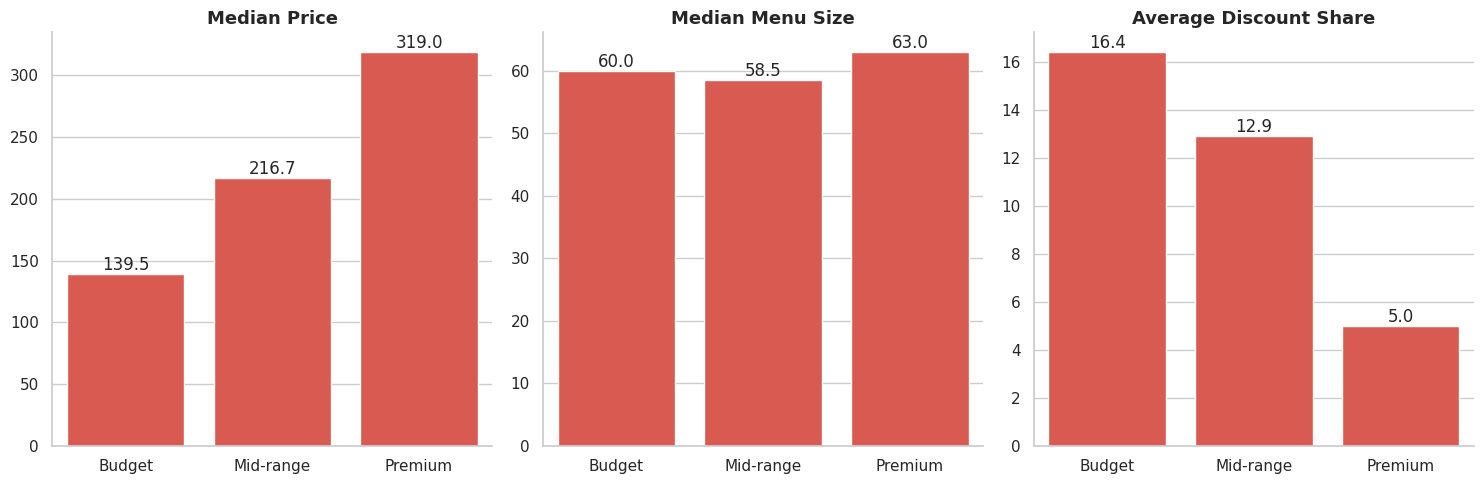

In [57]:
# Compare key metrics across price segments

fig, axes = plt.subplots(
    1, 3,
    figsize=(15, 5)
)

for ax, metric, title in zip(
    axes,
    ["median_price", "median_menu_size", "avg_discount_share"],
    ["Median Price", "Median Menu Size", "Average Discount Share"]
):

    sns.barplot(
        data=segment_stats,
        x="price_segment",
        y=metric,
        color=colors[4],
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f")

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")

sns.despine()
plt.tight_layout()

plt.show()

**Market Segmentation Findings**

Restaurants were divided into **Budget**, **Mid-range**, and **Premium** segments based on their median menu price, with each segment containing exactly **78 restaurants** to ensure a balanced comparison.

As expected, median prices increase substantially across segments, from **140 UAH** in Budget restaurants to **319 UAH** in Premium restaurants.

Menu size remains relatively stable across all segments (**59-63 items**), suggesting that premium positioning is driven by **pricing** rather than assortment breadth.

Promotional activity shows the opposite pattern. **Budget** restaurants discount an average of **16.4%** of menu items, compared with **12.9%** in **Mid-range** restaurants and only **5.0%** in **Premium** restaurants.

Overall, lower-priced restaurants rely more heavily on discounts, while premium restaurants compete primarily through **pricing and positioning** rather than promotional activity.

### **9.2. Cuisine Composition by Price Segment**

In [58]:
# Split cuisine tags

segment_cuisines = (
    product_categories[
        [
            "restaurant_key",
            "cuisine_type_en"
        ]
    ]
    .drop_duplicates()
    .merge(
        restaurant_segments[
            [
                "restaurant_key",
                "price_segment"
            ]
        ],
        on="restaurant_key"
    )
)

segment_cuisines = (
    segment_cuisines.assign(
        cuisine_type_en=lambda x: x["cuisine_type_en"].str.split(", ")
    )
    .explode("cuisine_type_en")
)

In [59]:
# Calculate cuisine distribution by segment

segment_cuisine_stats = (
    segment_cuisines.groupby(
        [
            "price_segment",
            "cuisine_type_en"
        ],
        observed=False
    )
    .size()
    .reset_index(name="restaurants")
)

segment_cuisine_stats["share_pct"] = (
    segment_cuisine_stats.groupby(
        "price_segment",
        observed=False
    )["restaurants"]
    .transform(lambda x: x / x.sum() * 100)
)

segment_cuisine_stats = (
    segment_cuisine_stats
    .round(1)
)

In [60]:
# Top cuisines within each segment

segment_cuisine_stats.sort_values(
    [
        "price_segment",
        "share_pct"
    ],
    ascending=[True, False]
).groupby("price_segment", observed=False).head(10)

,price_segment,cuisine_type_en,restaurants,share_pct
8,Budget,Fast Food,29,19.7
6,Budget,Desserts & Coffee,17,11.6
12,Budget,International,14,9.5
15,Budget,Pizza,12,8.2
4,Budget,Breakfast,11,7.5
14,Budget,Kebab & Shawarma,11,7.5
3,Budget,Bakery,9,6.1
18,Budget,Ukrainian,9,6.1
5,Budget,Burgers,8,5.4
0,Budget,American,7,4.8


In [61]:
# Prepare cuisine share matrix by price segment

pivot = (
    segment_cuisine_stats
    .pivot(
        index="price_segment",
        columns="cuisine_type_en",
        values="share_pct"
    )
    .fillna(0)
)

# Keep logical segment order

pivot = pivot.reindex(
    ["Budget", "Mid-range", "Premium"]
)

# Sort cuisines from Premium-oriented to Budget-oriented

sort_order = (
    pivot.loc["Premium"]
    - pivot.loc["Budget"]
).sort_values(ascending=False).index

pivot = pivot[sort_order]

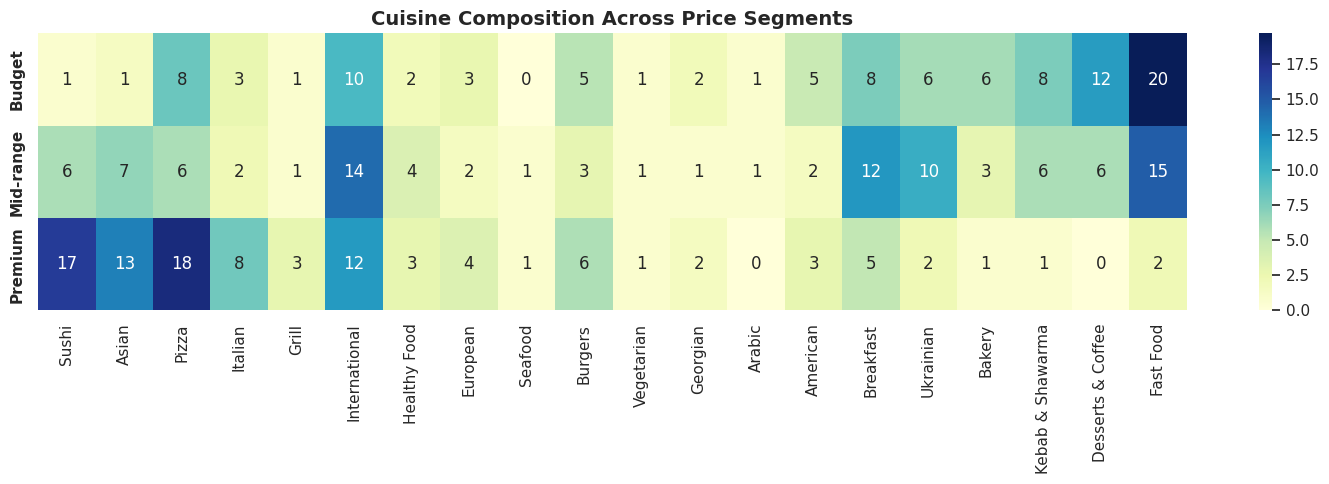

In [62]:
# Visualize cuisine composition across price segments

plt.figure(figsize=(15, 5))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Cuisine Composition Across Price Segments", fontsize=14, fontweight="bold")

plt.xlabel("")
plt.ylabel("")

plt.yticks(fontweight="bold")

plt.tight_layout()

plt.show()

**Cuisine Composition by Price Segment**

The cuisine mix differs substantially across restaurant price segments:

- **Budget** restaurants are dominated by **Fast Food** (19.7%), **Desserts & Coffee** (11.6%), and **International** cuisine (9.5%). These concepts are typically associated with affordability, convenience, and frequent ordering behavior.

- **Mid-range** restaurants show the most balanced composition. **Fast Food** (14.8%), **International** (14.1%), **Breakfast** (11.9%), and **Ukrainian** cuisine (10.4%) all maintain meaningful shares, indicating a broad mix of everyday dining options.

- **Premium** restaurants are strongly concentrated in **Pizza** (18.2%), **Sushi** (16.8%), **Asian** cuisine (13.1%), and **Italian** cuisine (8.0%). These cuisines are substantially more common among higher-priced restaurants than among budget concepts.

The heatmap highlights a clear distinction between market segments. **Budget** restaurants are associated with convenience-oriented cuisines such as Fast Food, Desserts & Coffee, and Kebab & Shawarma, while **Premium** restaurants are primarily concentrated in Pizza, Sushi, Asian, and Italian cuisine segments.

Overall, restaurant positioning on Glovo appears to be closely associated with **cuisine type**, with different cuisines occupying distinct price tiers within the marketplace.

## **10. Key Insights**

**1. The Glovo marketplace in Lviv is dominated by a handful of cuisines**

The top 10 cuisine segments account for approximately 79% of total cuisine presence, with **Fast Food, International, Pizza, Breakfast,** and **Sushi** alone representing more than 50% of all restaurant cuisine tags. This directly answers what cuisines dominate the market — and signals where competitive pressure is highest for any restaurant entering or benchmarking against these segments.

**2. Menu assortment varies significantly across cuisines**

The median Glovo restaurant offers **60 menu items**, although menu size ranges from just 3 to over 212 items. **American, Sushi, and Desserts & Coffee** restaurants operate the largest assortments, while **Vegetarian** and **Grill** concepts compete with more focused menus. This suggests that assortment strategy is strongly influenced by cuisine positioning rather than marketplace norms.

**3. Drinks, Desserts, and Sushi & Rolls are the categories with the broadest product assortment**

These three categories alone account for over 33% of all menu items on the platform, with the top 8 categories covering nearly 69% of total assortment — showing that customer choice on Glovo is concentrated in a small set of core categories despite the platform's overall diversity.

**4. Prices differ substantially by cuisine and category, but median is the reliable benchmark**

**Sushi** (315 UAH), **Italian** (289 UAH), and **Asian** (279 UAH) have the highest median prices, while **Arabic** (107 UAH) and **Bakery** (140 UAH) are the most affordable. At the category level, **Burritos, Wraps & Tacos** (404 UAH) and **Sets & Combos** (396 UAH) command the highest prices. Several cuisines (Grill, Sushi, Burgers) show large average-median gaps, meaning **average price overstates typical pricing** due to premium outliers like seafood platters and party sets.

**5. Discounts are common but shallow — used as a visibility tool, not a pricing lever**

Only 13.3% of menu items carry a discount, and most discounts cluster at 10-20%. **Desserts & Coffee** (38.8%) and **Kebab & Shawarma** (31.8%) discount most frequently but shallowly, while **Pizza (4.8%)** discounts relatively rarely but deeply, **Sushi (10.9%)** combines moderate promotional frequency with one of the highest average discount levels (22%).

**6. Bestseller tags are concentrated in categories built around flagship products**

Only 3.2% of menu items are marked as bestsellers, yet 83% of restaurants use this merchandising tool. **Business Lunches** (19.6%), **Burritos, Wraps & Tacos** (17.1%), and **Georgian Cuisine** (13.7%) show the highest bestseller concentration — categories with a narrow, focused product range where a few items can dominate customer attention.

**7. Price, discounting, and cuisine positioning are interconnected**

Restaurants split evenly into Budget (140 UAH median), Mid-range (217 UAH), and Premium (319 UAH) segments. Discounting drops sharply as price tier rises — from 16.4% of items in Budget to just 5.0% in Premium — while cuisine mix shifts from **Fast Food**-led Budget restaurants to **Pizza, Sushi,** and **Asian**-led Premium restaurants. This confirms a clear relationship between price, discounts, and market positioning.

---

## **11. Business Recommendations**

**1. Benchmark cuisine choice against marketplace saturation**

A restaurant entering or repositioning on Glovo in Lviv should recognize that Fast Food, International, Pizza, Breakfast, and Sushi face the most intense competition. Less saturated cuisines (Arabic, Seafood, Vegetarian, Grill) offer lower competition but also smaller existing demand — a trade-off to weigh when selecting market positioning.

**2. Size the menu according to cuisine norms, not a fixed target**

Restaurants competing in Sushi, American, or Desserts & Coffee should expect to offer 70-95 items to match category norms, while Grill or Vegetarian concepts can remain competitive with 20-50 items. Menu size should be benchmarked against cuisine-specific medians rather than the marketplace-wide median of 60 items.

**3. Use median price as the pricing benchmark, not average**

Because premium outliers (seafood platters, party sets, large combos) inflate average prices in several cuisines, any restaurant pricing its own menu — or this notebook's companion restaurant — against the market should compare against **median price by cuisine and category**, not average, to avoid mispricing relative to typical customer expectations.

**4. Choose a discount strategy that matches cuisine and price positioning**

Restaurants in visibility-driven categories (Desserts & Coffee, Kebab & Shawarma) benefit from frequent, shallow discounts (10%). Restaurants in premium categories (Pizza, Sushi) should reserve deeper discounts (20%+) for occasional demand-driving campaigns rather than constant promotion, which could undercut premium positioning.

**5. Reserve bestseller tags for a small, deliberate set of flagship items**

Categories with focused assortments (Business Lunches, Burritos, Georgian Cuisine) gain the most from bestseller merchandising. A restaurant with a broad menu (large Drinks or Desserts assortment) should resist tagging too many items as bestsellers, as this dilutes the signal's effectiveness for guiding customer choice.

**6. Decide price segment first, then align cuisine and promotional strategy**

Since price segment strongly predicts both cuisine mix and discount behavior, any restaurant — including the one benchmarked in the companion Kaggle dataset — should first determine its target segment (Budget, Mid-range, or Premium) and then align cuisine selection, menu size, and discount frequency to match that segment's established norms on Glovo.

---

## **Final Conclusion**

This notebook analyzed the **Glovo food delivery marketplace in Lviv**, building on the earlier restaurant market dataset to create a foundation for competitive benchmarking. Across **234 restaurants** and **15,898 menu items**, the analysis addressed each of the original business questions: which cuisines dominate, how menus are structured, how pricing and discounting vary, and how bestseller merchandising is used.

The marketplace is **highly concentrated by cuisine** — Fast Food, International, Pizza, Breakfast, and Sushi account for over half of all cuisine presence, defining the most competitive segments on the platform. Menu structure and product assortment are similarly concentrated, with Drinks, Desserts, and Sushi & Rolls forming the backbone of marketplace variety.

**Pricing** follows a consistent mid-range core (109-330 UAH) with a long premium tail driven by large-format meals and seafood platters, making **median price** the more reliable benchmark across cuisines and categories. **Discounting** is used deliberately rather than uniformly: some cuisines rely on frequent shallow discounts to stay visible, while others reserve deeper discounts for selective campaigns — and this pattern intensifies at the restaurant level, where Premium restaurants discount three times less often than Budget restaurants.

Most importantly, this analysis confirms that **cuisine, price, and promotional strategy are not independent decisions** — they form a connected positioning system already visible across the Glovo marketplace. This gives a clear, data-backed foundation for the next stage of competitive benchmarking: comparing how an individual restaurant's pricing, menu structure, and promotional activity measure up against the market norms established in this notebook.

##**Tableau-ready dataset**

In [63]:
# Create Tableau-ready Glovo dataset

tableau_df = product_categories.copy()

restaurant_metrics = (
    product_categories
    .groupby(["restaurant_key", "restaurant_name_clean"])
    .agg(
        median_price=("final_price", "median"),
        menu_size=("dish_name_original", "count"),
        discount_share=("is_discounted", "mean")
    )
    .reset_index()
)
restaurant_metrics["discount_share"] *= 100

restaurant_metrics["price_segment"] = pd.qcut(
    restaurant_metrics["median_price"],
    q=3,
    labels=["Budget", "Mid-range", "Premium"]
)

tableau_df = tableau_df.merge(
    restaurant_metrics,
    on=["restaurant_key", "restaurant_name_clean"],
    how="left",
    validate="many_to_one"
)

tableau_df["rating_group"] = pd.cut(
    tableau_df["rating_clean"],
    bins=[0, 4.0, 4.5, 5.0],
    labels=["Low", "Medium", "High"],
    include_lowest=True
)

tableau_df["price_group"] = pd.qcut(
    tableau_df["final_price"],
    q=4,
    labels=["Budget", "Mid-low", "Mid-high", "Premium"]
)

bestseller_keys = (
    df[df["menu_category_group"].eq("Bestsellers")]
    [["restaurant_key", "dish_name_original"]]
    .drop_duplicates()
    .assign(is_bestseller=True)
)

tableau_df = tableau_df.merge(
    bestseller_keys,
    on=["restaurant_key", "dish_name_original"],
    how="left",
    validate="many_to_one"
)
tableau_df["is_bestseller"] = tableau_df["is_bestseller"].eq(True)

final_columns = [
    "restaurant_key", "restaurant_name_clean", "rating_clean", "rating_group", "is_new_restaurant",
    "cuisine_type", "cuisine_type_en",
    "menu_category_clean", "menu_category_group",
    "dish_name_original", "dish_name_translit", "dish_description",
    "regular_price", "discount_price", "final_price", "price_group",
    "is_discounted", "discount_pct", "is_bestseller",
    "median_price", "menu_size", "discount_share", "price_segment"
]
tableau_df = tableau_df[final_columns].copy()

cuisine_tags = (
    tableau_df[["restaurant_key", "restaurant_name_clean", "cuisine_type_en"]]
    .drop_duplicates()
    .assign(cuisine_tag=lambda x: x["cuisine_type_en"].str.split(", "))
    .explode("cuisine_tag")
)
cuisine_tags["cuisine_tag"] = cuisine_tags["cuisine_tag"].str.strip()
cuisine_tags = (
    cuisine_tags[["restaurant_key", "restaurant_name_clean", "cuisine_tag"]]
    .drop_duplicates()
)